## Setup: Only for Google Colab

**If you are running this notebook locally, skip this section** — the helper files and data already sit next to the notebook.

On Google Colab, run the cells below first. They fetch the helper modules and data for this tutorial from the [BAMB2026 GitHub repository](https://github.com/bambschool/BAMB2026) and install the required packages. Check the left sidebar afterwards to confirm the files appeared, and make sure there are no download or installation errors.

In [ ]:
# Base path to the Module 4 files in the BAMB2026 GitHub repository
RAW = 'https://raw.githubusercontent.com/bambschool/BAMB2026/Module-4/Module%204/'

# Foraging dataset (into ./data/)
!mkdir -p data
data_files = ['wu2025minecraft.feather']
for f in data_files:
    !wget -q -O data/{f} "{RAW}data/{f}"

# Minecraft environment grids used in this notebook (into ./environments/)
!mkdir -p environments
env_files = ['smooth.12.csv', 'smooth.3.csv', 'random.14.csv', 'random.19.csv']
for f in env_files:
    !wget -q -O environments/{f} "{RAW}environments/{f}"

print('Downloads complete.')

In [ ]:
# Install required packages
!pip install -q numpy matplotlib scipy seaborn pandas pyarrow

That is everything Colab needs. The rest of the notebook runs identically on Colab and locally. **Now continue below.**

---

# Tutorial: Gaussian Process Regression as Bayesian Value Function Approximation

**Prepared by:** Charley M. Wu (TU Darmstadt; [hmc-lab.com](https://hmc-lab.com/)) for the 2026 Barcelona Summer School for Advanced Modeling of Behavior (BAMB; https://www.bambschool.org/)

**Module 4 // Day 1 // Block 3**


Welcome to this tutorial on **Gaussian Process regression** (GP; Rasmussen & Williams, 2006) and its application in reinforcement learning. The previous notebooks introduced model-based RL (DYNA-Q) and the Chinese Restaurant Process (CRP), combining both into a nonparametric context learning (DINER). Here we take a different angle on structure learning: instead of learning discrete environment models, we'll learn a continuous *value function*. This supports reward generalization by using the mechanisms of extrapolation and interpolation to predict which unobserved options are promising to explore.

A key assumption is that rewards are often structured in a correlated fashion. **Spatial structure** is common in the real world, with rich food patches, pleasant beaches, or cool cafes often clustered together. An agent that generalizes appropriately can more efficiently find better rewards, by infering the value of unvisited options from nearby observations.

This tutorial is built around the **GP-UCB** model (Srinivas et al., 2010), which myself and colleagues have used as a cognitive model of human learning in structured bandit environments (Wu et al., 2018; Giron et al., 2023). As a model of human cognition, it proposes that people form probabilistic beliefs about the value of novel options, and balance *exploration* (seeking uncertain regions) with *exploitation* (choosing high-expected-value options). We've even applied it to abstract/non-spatial features (Wu et al., 2020), graph-structured rewards (Wu et al., 2021), social settings (Witt et al., 2024), and under memory limitations (Ten et al., 2025). So needless to say, it's a very robust and versatile framework. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

def set_seed(seed=0):
    np.random.seed(seed)

set_seed(2026)
plt.rcParams['figure.dpi'] = 110

---
## 1. From Weight-Space to Function-Space

> **Roadmap for this section:** We'll use Bayesian linear regression (BLR) as a stepping stone to GPs. This gets us started with thinking in Bayesian terms. We will then swap out the explicit basis functions for something far more flexible: a **kernel**. That swap leads directly to Gaussian Processes. If the math gets heavy at any point, focus on the **boxed results** and the plots. The derivations are only here if you want to follow along.

### Bayesian linear regression: the weight-space view

In **Bayesian linear regression** (BLR), we describe outputs as a linear combination of *features* of the input, then maintain a probability distribution over the weights rather than committing to a single best fit. This is in contrast to *frequentist* regression, where we obtain a point-estimate of the weights (e.g., by minimizing squared error).

Given an input $x$, we map it through a **basis function** $\boldsymbol{\phi}(x) \in \mathbb{R}^m$ and model the output as:
$$
y = \boldsymbol{\phi}(x)^\top \mathbf{w} + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, \sigma_n^2)
$$
where $\mathbf{w} \in \mathbb{R}^m$ is a weight vector and $\varepsilon$ is i.i.d. Gaussian noise. The choice of $\boldsymbol{\phi}$ determines what kinds of functions the model can express (e.g., polynomial terms, sinusoids, radial basis functions, etc). We'll talk more about the basis function later.

**Prior.** We can express a preference for simpler functions by placing a zero-mean Gaussian prior on the weights:
$$\mathbf{w} \sim \mathcal{N}(\mathbf{0},\, \sigma_w^2 \mathbf{I})$$

**Likelihood.** For $n$ training observations, we stack the feature vectors row-wise into a design matrix $\boldsymbol{\Phi} \in \mathbb{R}^{n \times m}$ (row $i$ is $\boldsymbol{\phi}(x_i)^\top$) and collect the outputs in $\mathbf{y} \in \mathbb{R}^n$:
$$p(\mathbf{y} \mid \boldsymbol{\Phi}, \mathbf{w}) = \mathcal{N}(\boldsymbol{\Phi}\mathbf{w},\, \sigma_n^2 \mathbf{I})$$

Thus, the likelihood also takes the form of a Gaussian, with a mean of $\boldsymbol{\Phi}\mathbf{w}$ and a variance of $\sigma_n^2 \mathbf{I}$.

**Posterior.** Using Bayes' rule, $p(\mathbf{w} \mid \mathbf{X}, \mathbf{y}) \propto p(\mathbf{y} \mid \boldsymbol{\Phi}, \mathbf{w})\,p(\mathbf{w})$.

> **Math/history note:** "Completing the square" is a common technique in linear algebra used for the derivation in the next section. Fun fact, the technique dates back to as early as 1800–1600 BCE based on Old Babylonian clay tablets. But if matrix calculus isn't your thing, **skip to the boxed result** below. The tl;dr is that the posterior is also Gaussian.

Since both the prior and likelihood are Gaussian, their product is also Gaussian (via conjugacy). Taking the log and completing the square, we get:
$$\ln p(\mathbf{w} \mid \mathbf{X}, \mathbf{y}) \propto -\frac{1}{2\sigma_n^2}\|\mathbf{y} - \boldsymbol{\Phi}\mathbf{w}\|^2 - \frac{1}{2\sigma_w^2}\|\mathbf{w}\|^2$$
Then, we can expand and collect terms in $\mathbf{w}$ to reveal a quadratic form $-\frac{1}{2}(\mathbf{w} - \boldsymbol{\mu}_w)^\top \boldsymbol{\Sigma}_w^{-1}(\mathbf{w} - \boldsymbol{\mu}_w)$. This can be simplified to a Gaussian:

$$\boxed{p(\mathbf{w} \mid \mathbf{X}, \mathbf{y}) = \mathcal{N}(\boldsymbol{\mu}_w,\, \boldsymbol{\Sigma}_w)}$$

with:
$$
\boldsymbol{\mu}_w = \frac{1}{\sigma_n^2}\,\boldsymbol{\Sigma}_w\,\boldsymbol{\Phi}^\top\mathbf{y}, \qquad
\boldsymbol{\Sigma}_w = \left(\frac{\boldsymbol{\Phi}^\top\boldsymbol{\Phi}}{\sigma_n^2} + \frac{\mathbf{I}}{\sigma_w^2}\right)^{\!-1}
$$

The posterior mean $\boldsymbol{\mu}_w$ thus moves from $\mathbf{0}$ (the prior) toward the ordinary least-squares solution $(\boldsymbol{\Phi}^\top\boldsymbol{\Phi})^{-1}\boldsymbol{\Phi}^\top\mathbf{y}$ as more data arrive. With limited data the prior precision ($\mathbf{I}/\sigma_w^2$) regularises the weights toward zero.

The posterior thus describes a **distribution over weights**: each sample $\mathbf{w}^{(s)} \sim \mathcal{N}(\boldsymbol{\mu}_w, \boldsymbol{\Sigma}_w)$ defines a candidate function $f^{(s)}(x) = \boldsymbol{\phi}(x)^\top \mathbf{w}^{(s)}$. This is the **weight-space view**.

### Example: Polynomial BLR

Choosing $\boldsymbol{\phi}(x) = [1,\, x,\, x^2,\, \ldots,\, x^d]^\top$ recovers **polynomial regression**. The posterior $\mathcal{N}(\boldsymbol{\mu}_w, \boldsymbol{\Sigma}_w)$ is now a distribution over polynomial coefficients. This means that each sampled function from the posterior corresponds to a different polynomial functions of degree $d$.

The code cell below defines the BLR helper functions. **Run it**, then continue to the Barcelona temperature example to see polynomial BLR in action.

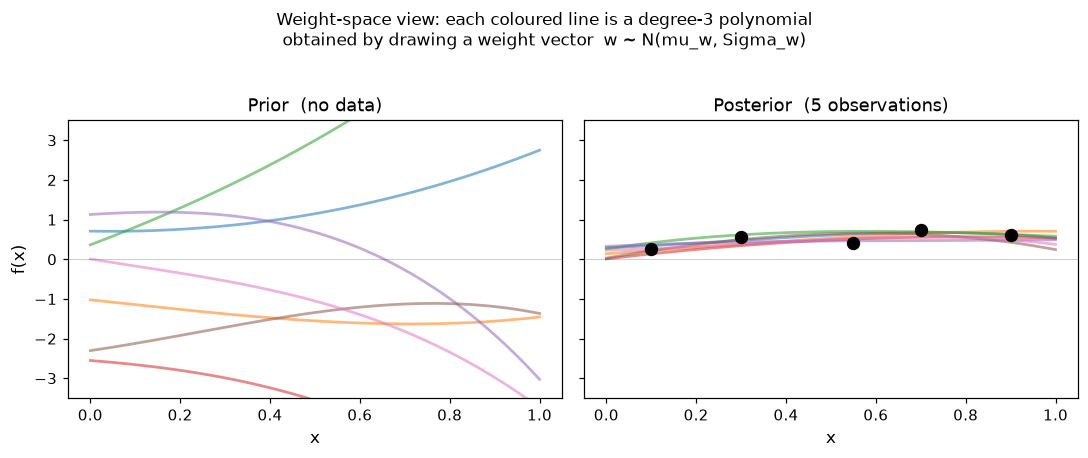

In [2]:
# --- Bayesian Linear Regression with polynomial basis functions ---

def poly_features(X, degree):
    """Polynomial basis: phi(x) = [1, x, x^2, ..., x^degree]."""
    X = np.asarray(X).flatten()
    return np.column_stack([X**d for d in range(degree + 1)])   # (n, degree+1)

def blr_posterior(X_train, y_train, degree, sigma_w=1.0, sigma_n=0.2):
    """
    Bayesian linear regression posterior over polynomial weights.

    Prior:      w ~ N(0, sigma_w^2 * I)
    Likelihood: y = Phi @ w + eps,  eps ~ N(0, sigma_n^2)

    Returns posterior mean mu_w and covariance Sigma_w.
    """
    Phi = poly_features(X_train, degree)         # (n, d+1)
    m   = Phi.shape[1]
    A   = Phi.T @ Phi / sigma_n**2 + np.eye(m) / sigma_w**2
    Sigma_w = np.linalg.solve(A, np.eye(m))
    mu_w    = (Sigma_w @ Phi.T @ y_train) / sigma_n**2
    return mu_w, Sigma_w

def blr_predict(X_test, mu_w, Sigma_w, degree, sigma_n=0.2):
    """Predictive mean and std at X_test."""
    Phi = poly_features(X_test, degree)          # (n_test, d+1)
    mu  = Phi @ mu_w
    var = np.einsum('ij,jk,ik->i', Phi, Sigma_w, Phi) + sigma_n**2
    return mu, np.sqrt(var)

def blr_sample_functions(X_test, mu_w, Sigma_w, degree, n_samples=5, seed=0):
    """Draw polynomial functions by sampling weight vectors from the posterior."""
    rng = np.random.RandomState(seed)
    m   = len(mu_w)
    L   = np.linalg.cholesky(Sigma_w + 1e-9 * np.eye(m))
    W   = mu_w[:, None] + L @ rng.randn(m, n_samples)    # (m, S)
    Phi = poly_features(X_test, degree)
    return (Phi @ W).T                                     # (S, n_test)

# --- Weight-space view: prior vs posterior function samples ---
X_vis   = np.linspace(0, 1, 200) #Which set of x-coordinates do we want to compute predictions?
X_obs   = np.array([0.1, 0.3, 0.55, 0.7, 0.9]) #Some aribtray observations
y_obs   = np.array([0.25, 0.55, 0.42, 0.73, 0.62])
deg_vis, sw_vis, sn_vis = 3, 1.5, 0.1

mu_prior  = np.zeros(deg_vis + 1) #priors
Sig_prior = sw_vis**2 * np.eye(deg_vis + 1)
mu_post, Sig_post = blr_posterior(X_obs, y_obs, deg_vis, sigma_w=sw_vis, sigma_n=sn_vis)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
configs = [
    ('Prior  (no data)',              mu_prior, Sig_prior, False),
    ('Posterior  (5 observations)',   mu_post,  Sig_post,  True),
]
for ax, (title, mu, Sig, show_data) in zip(axes, configs):
    for f in blr_sample_functions(X_vis, mu, Sig, deg_vis, n_samples=7, seed=12):
        ax.plot(X_vis, f, alpha=0.55, linewidth=1.8)
    if show_data:
        ax.scatter(X_obs, y_obs, color='black', zorder=5, s=60)
    ax.set_ylim(-3.5, 3.5)
    ax.axhline(0, color='k', linewidth=0.5, alpha=0.25)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('x', fontsize=11)
axes[0].set_ylabel('f(x)', fontsize=11)
plt.suptitle('Weight-space view: each coloured line is a degree-3 polynomial\n'
             'obtained by drawing a weight vector  w ~ N(mu_w, Sigma_w)',
             fontsize=11, y=1.03)
plt.tight_layout()
plt.show()

The plot above shows the weight-space view directly. Each coloured line is one candidate polynomial function obtained by drawing a weight vector $\mathbf{w}^{(s)}$ from the prior or posterior and evaluating $f^{(s)}(x) = \boldsymbol{\phi}(x)^\top \mathbf{w}^{(s)}$. However, for making predictions we only need these functions, not the weight vectors themselves. It turns out that all prediction quantities in BLR depend on the inputs only through a **similarity function** called the kernel.

### The kernel trick: uncoupling features from predictions

Consider the **prior** predictive covariance between two inputs $x$ and $x'$. With $\mathbf{w} \sim \mathcal{N}(\mathbf{0}, \sigma_w^2\mathbf{I})$:
$$\mathrm{Cov}[f(x),\, f(x')] = \boldsymbol{\phi}(x)^\top\,\mathrm{Cov}[\mathbf{w}]\,\boldsymbol{\phi}(x') = \sigma_w^2\,\boldsymbol{\phi}(x)^\top\boldsymbol{\phi}(x')$$

The $\sigma_w^2$ factor is just an overall scale. The essential structure that all predictions depend on is the **inner product between feature vectors**. We define the **kernel** to capture exactly this:
$$k(x, x') \;=\; \boldsymbol{\phi}(x)^\top\boldsymbol{\phi}(x')$$

For a polynomial basis, this gives the **polynomial kernel** $k_\mathrm{poly}(x, x') = \sum_{i=0}^{d}(x\,x')^i$. One can show that *all prediction quantities* in BLR (i.e., the posterior mean at a new point, the predictive variance, and the marginal likelihood) can be rewritten to only depend on inputs via pairwise kernel evaluations $k(x_i, x_j)$.

This is the **kernel trick**: if predictions depend only on $k$, we can **define the kernel directly** without specifying $\boldsymbol{\phi}$ at all. Any positive semi-definite function $k$ implicitly corresponds to an inner product in some (possibly infinite-dimensional) feature space, though we never need to construct $\boldsymbol{\phi}$ explicitly.

By replacing the feature map with a kernel, we move from the **weight-space view** (prior over weights) to the **function-space view** (a prior placed directly over functions). This is precisely what a **Gaussian Process** does.

> **Key takeaway:** The kernel $k(x, x')$ encodes how similar two inputs are. Once we design the kernel directly, bypassing explicit basis functions, we shift from asking "what degree polynomial?" to asking "how fast do correlations decay with distance?" That question is far more natural for modelling spatial structure, and it is precisely what a GP prior formalizes.

### Predicting Barcelona temperature anomalies: the extrapolation problem

Bayesian Linear Regression with a Gaussian prior is naturally **regularized**. But polynomial regression has a deeper limitation that no amount of regularisation can fix: **polynomials eventually diverge outside the training range**.

To illustrate this, we extend the x-axis three months before January and after December (shaded blue region = training domain). We will then compare two different polynomial models:

- **Degree 3**: the cubic fit is smooth within the year but systematically biased, as it cannot represent the true sinusoidal shape. Posterior samples are all cubic-shaped, none of which trace the true seasonal arc. Outside the year, the cubic model diverges quite substantially.

- **Degree 12**: with a very weak prior ($\sigma_w = 50$), the polynomial nearly interpolates all 12 training points, but oscillates between them inside the training range. Outside the year, both the mean and samples diverge sharply.

Both failures motivate moving from a fixed polynomial family to a prior that directly encodes *smoothness*, without committing to a specific parametric level of complexity (i.e., by directly specifying the degree).

**Exercise 1.** Try `degree=6`. Does a degree-6 polynomial avoid both failure modes *inside* the training domain? What happens outside the year?

**Exercise 2.** Set `sigma_w=0.01` for degree 12 (very strong prior). Does heavy regularization suppress the divergence in the samples outside the training range?

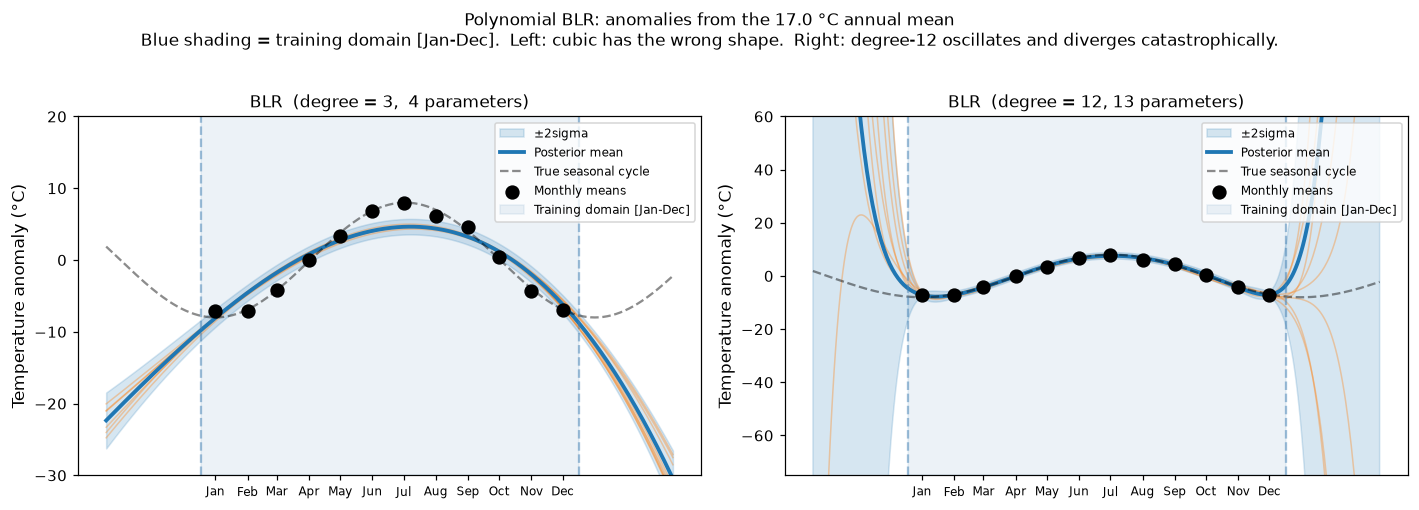

In [3]:
# --- Barcelona temperature: polynomial BLR and the extrapolation problem ---

# Approximate day-of-year at the midpoint of each calendar month
day_mid = np.array([15., 46., 74., 105., 135., 166., 196., 227., 258., 288., 319., 349.])
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

def true_temp(day):
    # Assume a smooth sinusoidal seasonal cycle for Barcelona (deg C)
    # The true data probably looks a bit different, but I couldn't be bothered to find the actual data
    return 17.0 - 8.0 * np.cos(2 * np.pi * (day - 15.) / 365.)

def norm_day(day):
    # Normalize day-of-year to the range [-1, 1] for numerical stability with high-degree polynomials
    return (day - 182.5) / 182.5

# Simulate 12 noisy monthly observations
rng_temp   = np.random.RandomState(7)
sigma_temp = 0.5
y_mean     = 17.0   # annual mean to align the GP zero-mean prior with the data
y_temp     = true_temp(day_mid) + rng_temp.randn(12) * sigma_temp - y_mean

X_train_temp = day_mid
X_train_norm = norm_day(day_mid)

# Extend x-axis 3 months outside the year to reveal extrapolation divergence
X_plot_days = np.linspace(-90., 455., 400)
X_plot_norm = norm_day(X_plot_days)

degree_configs_temp = [
    (3,  1.0, 'BLR  (degree = 3,  4 parameters)'),
    (12, 50.0, 'BLR  (degree = 12, 13 parameters)'),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (degree, sigma_w, title) in zip(axes, degree_configs_temp):
    mu_w, Sig_w    = blr_posterior(X_train_norm, y_temp, degree, sigma_w=sigma_w, sigma_n=sigma_temp)
    mu_pred, std_p = blr_predict(X_plot_norm, mu_w, Sig_w, degree, sigma_n=sigma_temp)

    for f in blr_sample_functions(X_plot_norm, mu_w, Sig_w, degree, n_samples=8, seed=3):
        ax.plot(X_plot_days, f, color='tab:orange', alpha=0.35, linewidth=1)

    ax.fill_between(X_plot_days, mu_pred - 2*std_p, mu_pred + 2*std_p,
                    color='tab:blue', alpha=0.18, label='±2sigma')
    ax.plot(X_plot_days, mu_pred, color='tab:blue', linewidth=2.5, label='Posterior mean')
    ax.plot(X_plot_days, true_temp(X_plot_days) - y_mean, 'k--', linewidth=1.5, alpha=0.45,
            label='True seasonal cycle')
    ax.scatter(X_train_temp, y_temp, color='black', zorder=5, s=70, label='Monthly means')

    # Mark training domain boundary
    ax.axvspan(1, 365, alpha=0.10, color='steelblue', zorder=0, label='Training domain [Jan-Dec]')
    ax.axvline(1,   color='steelblue', linewidth=1.5, linestyle='--', alpha=0.5)
    ax.axvline(365, color='steelblue', linewidth=1.5, linestyle='--', alpha=0.5)

    ax.set_xticks(day_mid)
    ax.set_xticklabels(month_labels, fontsize=8)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Temperature anomaly (°C)', fontsize=11)
    ax.legend(fontsize=8, loc='upper right')

axes[0].set_ylim(-30, 20)
axes[1].set_ylim(-75, 60)   # clipped -- degree-12 samples diverge beyond this

plt.suptitle('Polynomial BLR: anomalies from the 17.0 °C annual mean\n'
             'Blue shading = training domain [Jan-Dec].  '
             'Left: cubic has the wrong shape.  Right: degree-12 oscillates and diverges catastrophically.',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


### From weight-space to function-space views

The two panels above illustrate why polynomial regression fails even with Bayesian regularization. The root cause is not overfitting. The Gaussian prior ensures the posterior mean remains reasonable within the data range, but the deeper problem is **model family mismatch**: by committing to the polynomial family, we bake in a basis that (1) diverges outside the training range, (2) requires manual degree selection, and (3) cannot encode periodicity or stationarity.

In Section 1 we derived that the prior predictive covariance of BLR depends on inputs only through the **kernel** $k(x, x') = \boldsymbol{\phi}(x)^\top \boldsymbol{\phi}(x')$. The **function-space view** starts here. Rather than defining features $\boldsymbol{\phi}$ and letting the kernel emerge, we define the kernel *directly*:

$$f \sim \mathcal{GP}(0, \mathbf{K})$$

meaning any finite collection $\{f(x_1), \ldots, f(x_n)\}$ is jointly Gaussian with covariance $K_{ij} = k(x_i, x_j)$. The kernel encodes our beliefs about function smoothness without committing to a polynomial degree.

The most widely used kernel is the **Radial Basis Function (RBF) kernel** (aka squared-exponential kernel):
$$k(x, x') = \exp\!\left(-\frac{\|x - x'\|^2}{2\lambda^2}\right)$$
Nearby inputs ($\|x - x'\| \ll \lambda$) get kernel value close to 1 (strongly correlated). Distant inputs get value close to 0. Crucially, the RBF kernel is **stationary** (depends only on distance, not absolute position) and **bounded**: predictions never diverge outside the training range; instead, the GP reverts to the prior mean with increasing uncertainty.

The cell below shows all three models on the same Barcelona data. Outside the training year, degree 3 and degree 12 diverge sharply, whereas GP defaults back to the prior with widening uncertainty bands.

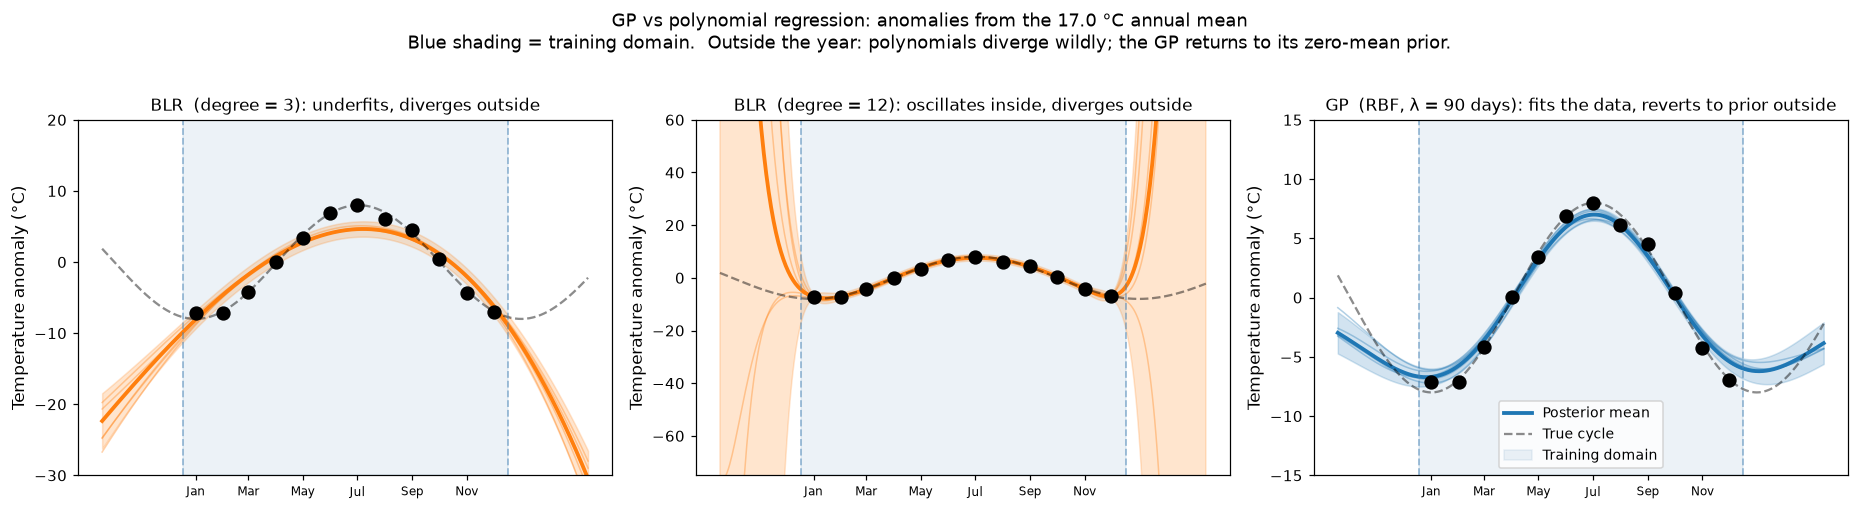

In [4]:
# Same 12 Barcelona monthly mean observations -- three models on the same extended x-axis.
# X_plot_days, X_plot_norm, X_train_temp, X_train_norm, y_temp, sigma_temp, day_mid, true_temp
# are all defined in the blr-viz cell above.
#
# Lightweight 1D GP helpers defined here (gp_posterior from the GP toolkit is not yet available).

def rbf_kernel_1d(X1, X2, lengthscale):
    X1 = np.asarray(X1).reshape(-1, 1)
    X2 = np.asarray(X2).reshape(-1, 1)
    return np.exp(-0.5 * cdist(X1, X2, 'sqeuclidean') / lengthscale**2)

def gp_posterior_1d(X_train, y_train, X_test, lengthscale=1.5, noise=0.1):
    n   = len(X_train)
    K   = rbf_kernel_1d(X_train, X_train, lengthscale) + noise**2 * np.eye(n)
    Ks  = rbf_kernel_1d(X_test,  X_train, lengthscale)
    Kss = rbf_kernel_1d(X_test,  X_test,  lengthscale)
    mu  = Ks @ np.linalg.solve(K, y_train)
    cov = Kss - Ks @ np.linalg.solve(K, Ks.T)
    std = np.sqrt(np.maximum(np.diag(cov), 0.0))
    return mu, std, cov

def gp_sample_1d(mu, cov, n_samples=5, seed=0):
    rng = np.random.RandomState(seed)
    L   = np.linalg.cholesky(cov + 1e-8 * np.eye(len(mu)))
    return (mu[:, None] + L @ rng.randn(len(mu), n_samples)).T

# -------------------------------------------------------------------------

blr_panels_temp = [
    (3,  1.0, 'BLR  (degree = 3): underfits, diverges outside'),
    (12, 50.0, 'BLR  (degree = 12): oscillates inside, diverges outside'),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

for ax, (deg, sigma_w, lbl) in zip(axes[:2], blr_panels_temp):
    mu_w, Sig_w    = blr_posterior(X_train_norm, y_temp, deg, sigma_w=sigma_w, sigma_n=sigma_temp)
    mu_pred, std_p = blr_predict(X_plot_norm, mu_w, Sig_w, deg, sigma_n=sigma_temp)
    for f in blr_sample_functions(X_plot_norm, mu_w, Sig_w, deg, n_samples=5, seed=5):
        ax.plot(X_plot_days, f, color='tab:orange', alpha=0.35, linewidth=1)
    ax.fill_between(X_plot_days, mu_pred - 2*std_p, mu_pred + 2*std_p,
                    color='tab:orange', alpha=0.20)
    ax.plot(X_plot_days, mu_pred, color='tab:orange', linewidth=2.5, label='Posterior mean')
    ax.scatter(X_train_temp, y_temp, color='black', zorder=5, s=70)
    ax.plot(X_plot_days, true_temp(X_plot_days) - y_mean, 'k--', linewidth=1.5, alpha=0.45,
            label='True cycle')
    ax.axvspan(1, 365, alpha=0.10, color='steelblue', zorder=0)
    ax.axvline(1,   color='steelblue', linewidth=1.2, linestyle='--', alpha=0.5)
    ax.axvline(365, color='steelblue', linewidth=1.2, linestyle='--', alpha=0.5)
    ax.set_xticks(day_mid[::2])
    ax.set_xticklabels(['Jan','Mar','May','Jul','Sep','Nov'], fontsize=8)
    ax.set_ylabel('Temperature anomaly (°C)', fontsize=11)
    ax.set_title(lbl, fontsize=11)

ax = axes[2]
mu_gp, std_gp, cov_gp = gp_posterior_1d(X_train_temp, y_temp, X_plot_days,
                                          lengthscale=90., noise=sigma_temp)
for f in gp_sample_1d(mu_gp, cov_gp, n_samples=5, seed=5):
    ax.plot(X_plot_days, f, color='tab:blue', alpha=0.35, linewidth=1)
ax.fill_between(X_plot_days, mu_gp - 2*std_gp, mu_gp + 2*std_gp, color='tab:blue', alpha=0.20)
ax.plot(X_plot_days, mu_gp, color='tab:blue', linewidth=2.5, label='Posterior mean')
ax.scatter(X_train_temp, y_temp, color='black', zorder=5, s=70)
ax.plot(X_plot_days, true_temp(X_plot_days) - y_mean, 'k--', linewidth=1.5, alpha=0.45, label='True cycle')
ax.axvspan(1, 365, alpha=0.10, color='steelblue', zorder=0, label='Training domain')
ax.axvline(1,   color='steelblue', linewidth=1.2, linestyle='--', alpha=0.5)
ax.axvline(365, color='steelblue', linewidth=1.2, linestyle='--', alpha=0.5)
ax.set_title('GP  (RBF, \u03bb = 90 days): fits the data, reverts to prior outside', fontsize=11)
ax.set_xticks(day_mid[::2])
ax.set_xticklabels(['Jan','Mar','May','Jul','Sep','Nov'], fontsize=8)
ax.set_ylabel('Temperature anomaly (°C)', fontsize=11)
ax.legend(fontsize=9)

axes[0].set_ylim(-30, 20)
axes[1].set_ylim(-75, 60)
axes[2].set_ylim(-15, 15)

plt.suptitle('GP vs polynomial regression: anomalies from the 17.0 °C annual mean\n'
             'Blue shading = training domain.  '
             'Outside the year: polynomials diverge wildly; the GP returns to its zero-mean prior.',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


---
## 2. The GP Toolkit

A Gaussian Process (Rasmussen & Williams, 2006) defines a distribution over functions through a kernel. Any finite collection of function values $\{f(x_1), \ldots, f(x_n)\}$ is jointly Gaussian:
$$
\mathbf{f} \sim \mathcal{N}(\mathbf{0},\, \mathbf{K})
$$
where $K_{ij} = k(x_i, x_j)$ is the **kernel matrix**. We write $f \sim \mathcal{GP}(0, k)$.

### GP posterior

Given noisy observations $\mathbf{y} = f(\mathbf{X}) + \boldsymbol{\varepsilon}$ with $\varepsilon \sim \mathcal{N}(\mathbf{0}, \sigma_n^2 \mathbf{I})$, the posterior at test inputs $x_*$ is:
$$
\mu(x) = k(x_*, \mathbf{X})\,\bigl[\mathbf{K}(\mathbf{X},\mathbf{X}) + \sigma_n^2 \mathbf{I}\bigr]^{-1} \mathbf{y}
$$
$$
\sigma^2(x_*) = k(x_*,x_*) - k(x_*, \mathbf{X})\,\bigl[\mathbf{K}(\mathbf{X},\mathbf{X}) + \sigma_n^2 \mathbf{I}\bigr]^{-1} k(\mathbf{X}, x_*)
$$

In the RL framing we'll use for the rest of this notebook:
- **$\mu(x_*)$** = the agent's best estimate of the reward at option $x_*$ → an estimated *value function*
- **$\sigma(x_*)$** = uncertainty about the reward at $x_*$ → a Bayesian confidence interval

Together, these form a **Bayesian value function approximation** that generalizes from visited to unvisited options through the kernel.

### The RBF kernel and the lengthscale

We'll use the **RBF (squared-exponential) kernel** throughout:
$$
k(x, x') = \exp\!\left(-\frac{\|x - x'\|^2}{2\lambda^2}\right)
$$
The **lengthscale** $\lambda$ controls how far an observation at $x$ informs the predicted value at $x'$. When $\|x - x'\| \ll \lambda$, the kernel is near 1 (strongly correlated). When $\|x - x'\| \gg \lambda$, the kernel is near 0 (effectively independent).

We'll work with inputs on the scale $[0, 10]$ throughout Sections 2–4, so the lengthscale is expressed in those same units. A value of $\lambda = 1$ means an observation informs its immediate neighbours (within ~1 unit); $\lambda = 2$ means it reaches roughly two tiles in each direction.

In [1]:
# ============================================================
# Core GP functions (used throughout the rest of the notebook)
# ============================================================

def rbf_kernel(X1, X2, lengthscale=1.0):
    """
    RBF (squared-exponential) kernel.

    k(x, x') = exp(-||x - x'||^2 / (2 * lengthscale^2))

    X1: (n1,) or (n1, d)   X2: (n2,) or (n2, d)
    Returns: (n1, n2) kernel matrix
    """
    X1 = np.atleast_2d(X1) if X1.ndim > 1 else X1.reshape(-1, 1)
    X2 = np.atleast_2d(X2) if X2.ndim > 1 else X2.reshape(-1, 1)
    return np.exp(-0.5 * cdist(X1, X2, metric='sqeuclidean') / lengthscale**2)


def gp_posterior(X_train, y_train, X_test, lengthscale=1.0, noise=0.1):
    """
    Compute GP posterior mean, std, and covariance.

    Parameters
    ----------
    X_train : (n,) or (n, d)   observed inputs
    y_train : (n,)              observed outputs
    X_test  : (m,) or (m, d)   test inputs
    lengthscale : float         RBF kernel lengthscale lambda
    noise       : float         observation noise std sigma_n

    Returns
    -------
    mu  : (m,)   posterior mean
    std : (m,)   posterior standard deviation
    cov : (m, m) posterior covariance matrix
    """
    n    = len(X_train)
    K    = rbf_kernel(X_train, X_train, lengthscale) + noise**2 * np.eye(n)
    K_s  = rbf_kernel(X_test,  X_train, lengthscale)   # (m, n)
    K_ss = rbf_kernel(X_test,  X_test,  lengthscale)   # (m, m)
    mu   = K_s @ np.linalg.solve(K, y_train)
    cov  = K_ss - K_s @ np.linalg.solve(K, K_s.T)
    std  = np.sqrt(np.maximum(np.diag(cov), 0.0))
    return mu, std, cov


def gp_sample(mu, cov, n_samples=5, seed=0):
    """Draw sample functions from a GP distribution N(mu, cov)."""
    rng = np.random.RandomState(seed)
    L   = np.linalg.cholesky(cov + 1e-8 * np.eye(len(mu)))
    return (mu[:, None] + L @ rng.randn(len(mu), n_samples)).T  # (S, n)


print('GP toolkit loaded.')

GP toolkit loaded.


### Anatomy of the GP posterior: visualising the matrices and vectors

The GP posterior formulae involve several matrices and vectors that each play a distinct role. For a training set $\mathbf{X} = \{x_1,\ldots,x_n\}$ with noisy observations $\mathbf{y}$, the posterior at a test point $x_*$ is:

$$\mu(x_*) = \underbrace{\mathbf{k}(x_*, \mathbf{X})}_{1 \times n} \underbrace{\left[\mathbf{K}(\mathbf{X},\mathbf{X}) + \sigma_n^2\mathbf{I}\right]^{-1}}_{n \times n} \underbrace{\mathbf{y}}_{n \times 1}$$

$$\sigma^2(x_*) = \underbrace{k(x_*,x_*)}_{\text{prior var.}} - \underbrace{\mathbf{k}(x_*,\mathbf{X})}_{1 \times n} \underbrace{\left[\mathbf{K}(\mathbf{X},\mathbf{X}) + \sigma_n^2\mathbf{I}\right]^{-1}}_{n \times n} \underbrace{\mathbf{k}(\mathbf{X},x_*)}_{n \times 1}$$

A useful shorthand is to precompute the **dual weight vector** $\boldsymbol{\alpha} = [\mathbf{K}(\mathbf{X},\mathbf{X}) + \sigma_n^2\mathbf{I}]^{-1}\mathbf{y}$ (solve once, reuse for any test point), so that $\mu_*(x) = \mathbf{k}(x,\mathbf{X})\,\boldsymbol{\alpha}$. Each element $\alpha_i$ is the "weight" that observation $y_i$ contributes to the prediction at any new point, scaled by how similar that point is to $x_i$.

The cell below visualizes all of these for a small example with $n = 6$ training points.

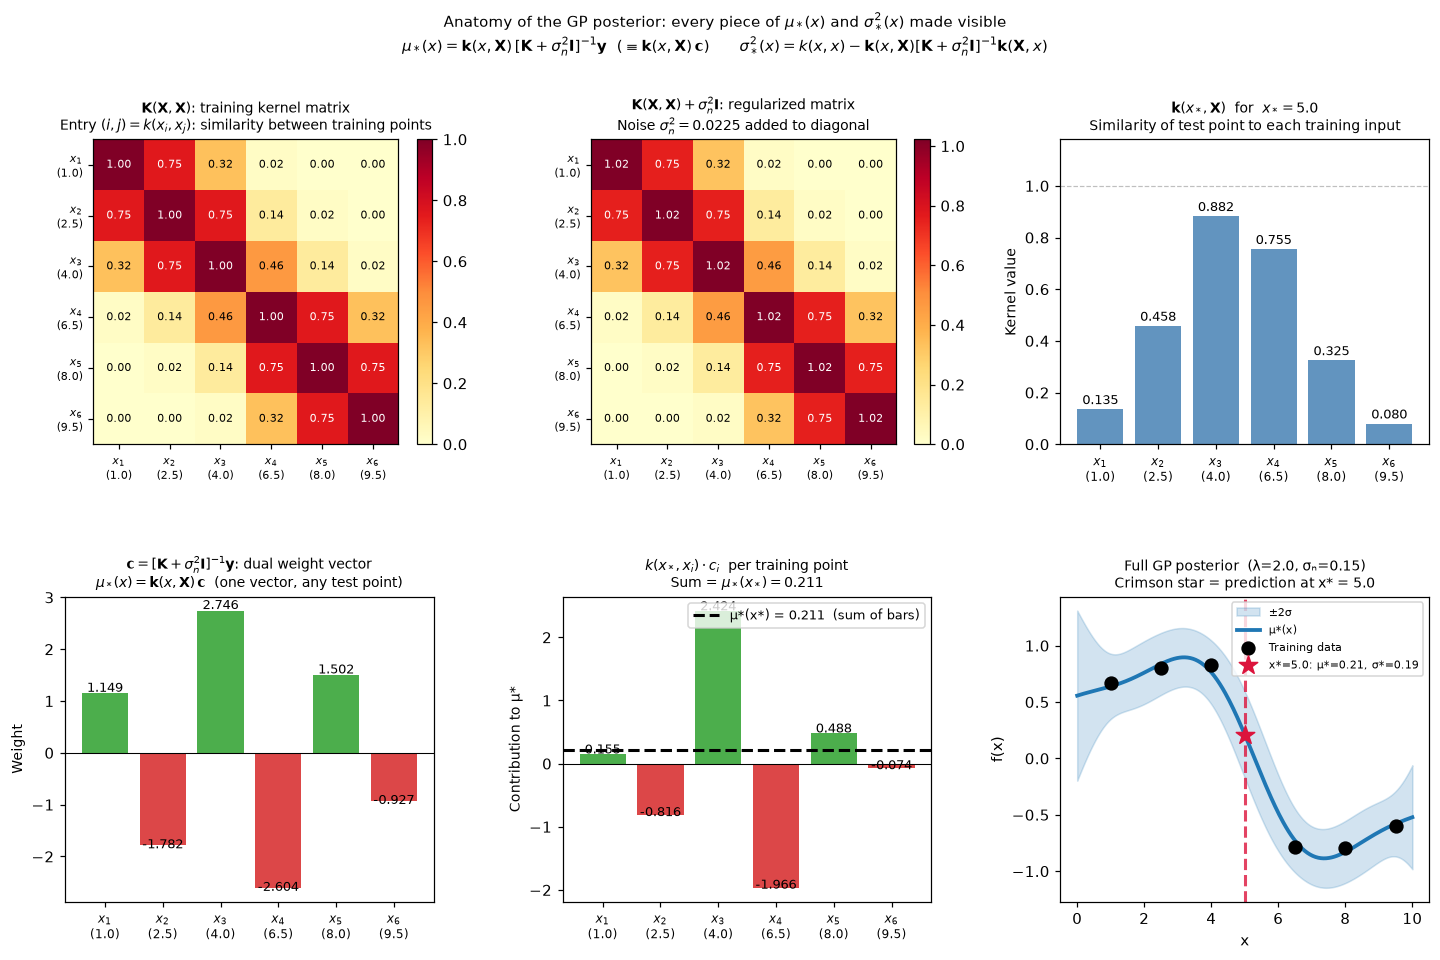

At x* = 5.0:  μ* = 0.2111,  σ*² = 0.0367,  σ* = 0.1916


In [6]:
# GP posterior anatomy: every matrix and vector for n=6 training points
# We highlight a single test point x* = 5.0 to trace through the full computation.

X_vis  = np.array([1.0, 2.5, 4.0, 6.5, 8.0, 9.5])
y_vis  = np.sin(0.6 * X_vis) + np.array([0.10, -0.20, 0.15, -0.10, 0.20, -0.05])
x_star = 5.0
ls_vis    = 2.0
noise_vis = 0.15
n_vis  = len(X_vis)

# Build all the pieces
K_XX    = rbf_kernel(X_vis, X_vis, ls_vis)                                # (n, n)
K_noisy = K_XX + noise_vis**2 * np.eye(n_vis)                             # (n, n)
k_s     = rbf_kernel(np.array([x_star]), X_vis, ls_vis).flatten()         # (n,)
k_ss    = rbf_kernel(np.array([x_star]), np.array([x_star]), ls_vis).item()  # .item() handles (1,1) array

c_vec     = np.linalg.solve(K_noisy, y_vis)   # dual weights (c = [K+σ²I]⁻¹y)
mu_star   = float(k_s @ c_vec)
var_star  = float(k_ss - k_s @ np.linalg.solve(K_noisy, k_s))

# ── Layout ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 9))
gs  = fig.add_gridspec(2, 3, hspace=0.50, wspace=0.35)
tick_lbl = [f'$x_{i+1}$\n({X_vis[i]:.1f})' for i in range(n_vis)]

def annotate_mat(ax, M, fmt='.2f'):
    vmax = M.max()
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            val = M[i, j]
            txt_color = 'white' if val > 0.6 * vmax else 'black'
            ax.text(j, i, format(val, fmt),
                    ha='center', va='center', fontsize=7.5, color=txt_color)

# ── (0,0) K(X,X) ─────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(K_XX, cmap='YlOrRd', vmin=0, vmax=1, aspect='equal')
plt.colorbar(im1, ax=ax1, fraction=0.046)
annotate_mat(ax1, K_XX)
ax1.set_xticks(range(n_vis)); ax1.set_yticks(range(n_vis))
ax1.set_xticklabels(tick_lbl, fontsize=7.5)
ax1.set_yticklabels(tick_lbl, fontsize=7.5)
ax1.set_title(r'$\mathbf{K}(\mathbf{X},\mathbf{X})$: training kernel matrix' + '\n'
              r'Entry $(i,j)=k(x_i,x_j)$: similarity between training points', fontsize=9)

# ── (0,1) K(X,X) + σ²I ───────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(K_noisy, cmap='YlOrRd', vmin=0, vmax=K_noisy.max(), aspect='equal')
plt.colorbar(im2, ax=ax2, fraction=0.046)
annotate_mat(ax2, K_noisy)
ax2.set_xticks(range(n_vis)); ax2.set_yticks(range(n_vis))
ax2.set_xticklabels(tick_lbl, fontsize=7.5)
ax2.set_yticklabels(tick_lbl, fontsize=7.5)
ax2.set_title(r'$\mathbf{K}(\mathbf{X},\mathbf{X})+\sigma_n^2\mathbf{I}$: regularized matrix' + '\n'
              r'Noise $\sigma_n^2=' + f'{noise_vis**2:.4f}' + r'$ added to diagonal', fontsize=9)

# ── (0,2) k(x*, X) bar chart ─────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.bar(range(n_vis), k_s, color='steelblue', alpha=0.85, zorder=2)
for i, v in enumerate(k_s):
    ax3.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=8.5)
ax3.set_xticks(range(n_vis))
ax3.set_xticklabels(tick_lbl, fontsize=8)
ax3.set_ylim(0, 1.18)
ax3.set_ylabel('Kernel value', fontsize=9)
ax3.set_title(r'$\mathbf{k}(x_*,\mathbf{X})$  for  $x_*=' + f'{x_star}$' + '\n'
              'Similarity of test point to each training input', fontsize=9)
ax3.axhline(1.0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)

# ── (1,0) α = [K+σ²I]⁻¹ y ───────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
colors4 = ['tab:green' if v >= 0 else 'tab:red' for v in c_vec]
ax4.bar(range(n_vis), c_vec, color=colors4, alpha=0.85, zorder=2)
for i, v in enumerate(c_vec):
    ax4.text(i, v + (0.03 if v >= 0 else -0.06), f'{v:.3f}', ha='center', fontsize=8.5)
ax4.axhline(0, color='black', linewidth=0.7)
ax4.set_xticks(range(n_vis))
ax4.set_xticklabels(tick_lbl, fontsize=8)
ax4.set_ylabel('Weight', fontsize=9)
ax4.set_title(r'$\mathbf{c}=[\mathbf{K}+\sigma_n^2\mathbf{I}]^{-1}\mathbf{y}$: dual weight vector' + '\n'
              r'$\mu_*(x) = \mathbf{k}(x,\mathbf{X})\,\mathbf{c}$  (one vector, any test point)', fontsize=9)

# ── (1,1) per-point contributions k(x*,xi)·αi ───────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
contribs = k_s * c_vec
colors5  = ['tab:green' if v >= 0 else 'tab:red' for v in contribs]
ax5.bar(range(n_vis), contribs, color=colors5, alpha=0.85, zorder=2)
for i, v in enumerate(contribs):
    ax5.text(i, v + (0.005 if v >= 0 else -0.015), f'{v:.3f}', ha='center', fontsize=8.5)
ax5.axhline(mu_star, color='black', linewidth=2, linestyle='--',
            label=f'μ*(x*) = {mu_star:.3f}  (sum of bars)')
ax5.axhline(0, color='black', linewidth=0.7)
ax5.set_xticks(range(n_vis))
ax5.set_xticklabels(tick_lbl, fontsize=8)
ax5.set_ylabel('Contribution to μ*', fontsize=9)
ax5.legend(fontsize=8.5)
ax5.set_title(r'$k(x_*,x_i)\cdot c_i$  per training point' + '\n'
              r'Sum = $\mu_*(x_*) = ' + f'{mu_star:.3f}$', fontsize=9)

# ── (1,2) full posterior with x* highlighted ─────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
X_test_vis = np.linspace(0, 10, 250)
mu_vis, std_vis, _ = gp_posterior(X_vis, y_vis, X_test_vis, lengthscale=ls_vis, noise=noise_vis)
ax6.fill_between(X_test_vis, mu_vis - 2*std_vis, mu_vis + 2*std_vis,
                 color='tab:blue', alpha=0.20, label='±2σ')
ax6.plot(X_test_vis, mu_vis, color='tab:blue', linewidth=2.5, label='μ*(x)')
ax6.scatter(X_vis, y_vis, color='black', zorder=5, s=70, label='Training data')
ax6.axvline(x_star, color='crimson', linewidth=2, linestyle='--', alpha=0.8)
ax6.scatter([x_star], [mu_star], color='crimson', zorder=6, s=160, marker='*',
            label=f'x*={x_star}: μ*={mu_star:.2f}, σ*={np.sqrt(var_star):.2f}')
ax6.set_xlabel('x', fontsize=10)
ax6.set_ylabel('f(x)', fontsize=10)
ax6.set_title(f'Full GP posterior  (λ={ls_vis}, σₙ={noise_vis})\n'
              f'Crimson star = prediction at x* = {x_star}', fontsize=9)
ax6.legend(fontsize=7.5, loc='upper right')

plt.suptitle(
    r'Anatomy of the GP posterior: every piece of $\mu_*(x)$ and $\sigma_*^2(x)$ made visible' + '\n' +
    r'$\mu_*(x)=\mathbf{k}(x,\mathbf{X})\,[\mathbf{K}+\sigma_n^2\mathbf{I}]^{-1}\mathbf{y}\ \ (\equiv\mathbf{k}(x,\mathbf{X})\,\mathbf{c})$'
    r'$\quad\quad$'
    r'$\sigma_*^2(x)=k(x,x)-\mathbf{k}(x,\mathbf{X})[\mathbf{K}+\sigma_n^2\mathbf{I}]^{-1}\mathbf{k}(\mathbf{X},x)$',
    fontsize=10, y=1.01
)
plt.show()

print(f'At x* = {x_star}:  μ* = {mu_star:.4f},  σ*² = {var_star:.4f},  σ* = {np.sqrt(var_star):.4f}')

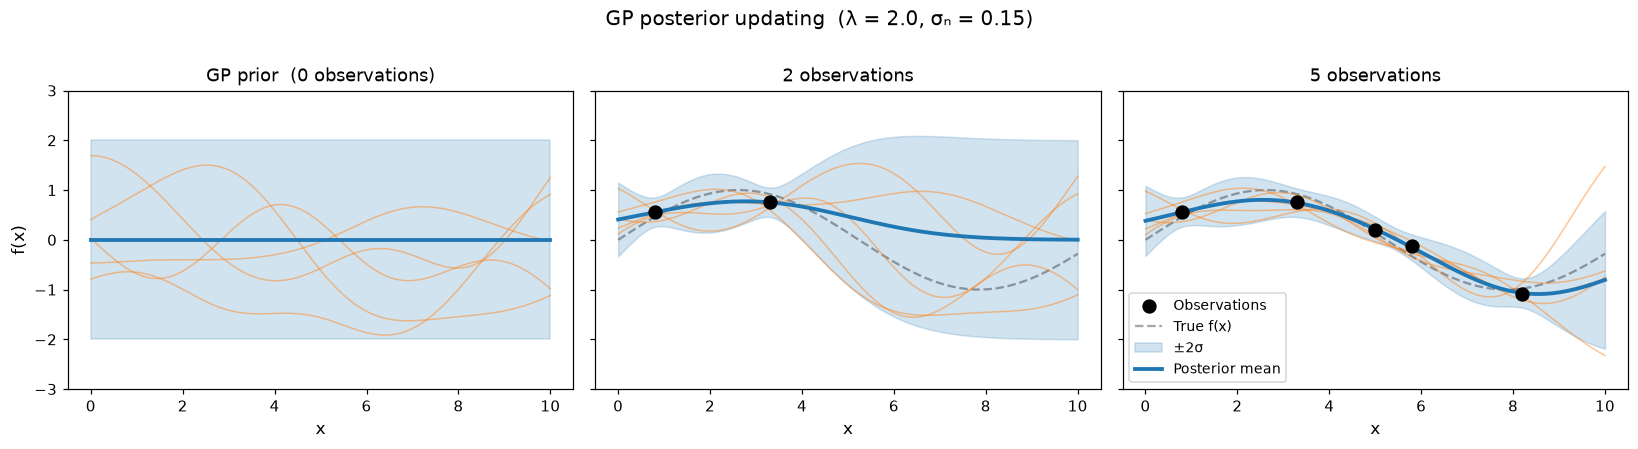

In [7]:
# 1-D GP posterior updating as observations accumulate
# Input space x ∈ [0, 10] - the same scale we'll use for the bandit grid

X_plot2  = np.linspace(0, 10, 300)
true_fn2 = lambda x: np.sin(0.6 * x)   # a smooth oscillation on [0, 10]

X_obs_pool = np.array([0.8, 3.3, 5.8, 8.2, 5.0])
y_obs_pool = true_fn2(X_obs_pool) + np.array([0.10, -0.15, 0.20, -0.12, 0.05])

lengthscale = 2.0   # <-- try changing this (try 0.5, 2.0, 5.0)
noise       = 0.15

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, n_pts in zip(axes, [0, 2, 5]):
    if n_pts == 0:
        K_prior = rbf_kernel(X_plot2, X_plot2, lengthscale)
        mu      = np.zeros(len(X_plot2))
        cov     = K_prior
    else:
        mu, _, cov = gp_posterior(
            X_obs_pool[:n_pts], y_obs_pool[:n_pts], X_plot2,
            lengthscale=lengthscale, noise=noise
        )
        ax.scatter(X_obs_pool[:n_pts], y_obs_pool[:n_pts],
                   color='black', zorder=5, s=70, label='Observations')
        ax.plot(X_plot2, true_fn2(X_plot2), 'k--', linewidth=1.5, alpha=0.35, label='True f(x)')

    std     = np.sqrt(np.maximum(np.diag(cov), 0.0))
    samples = gp_sample(mu, cov, n_samples=5, seed=7)
    for s in samples:
        ax.plot(X_plot2, s, color='tab:orange', alpha=0.45, linewidth=1)
    ax.fill_between(X_plot2, mu - 2*std, mu + 2*std, color='tab:blue', alpha=0.20, label='±2σ')
    ax.plot(X_plot2, mu, color='tab:blue', linewidth=2.5, label='Posterior mean')
    label = 'GP prior  (0 observations)' if n_pts == 0 else f'{n_pts} observation{"s" if n_pts>1 else ""}'
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('x', fontsize=11)
    ax.set_ylim(-3, 3)

axes[0].set_ylabel('f(x)', fontsize=11)
axes[2].legend(fontsize=9)
plt.suptitle(f'GP posterior updating  (λ = {lengthscale}, σₙ = {noise})', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### The lengthscale: how far does an observation reach?

The lengthscale $\lambda$ is the single most important hyperparameter. It encodes the agent's prior belief about the *spatial scale* of correlations in the environment. Cognitively, we can think of it as **generalisation distance**: how far from an observed point does the observation remain informative?

- **Small $\lambda$ (e.g. 0.5)**: each observation only informs predictions at very nearby inputs; the posterior mean is 'spiky' and the uncertainty collapses sharply away from data.
- **Large $\lambda$ (e.g. 4.0)**: an observation informs predictions far away; the posterior mean is globally smooth.

In Wu et al. (2018), the two environment conditions were characterized by $\lambda = 1$ (rough) and $\lambda = 2$ (smooth), which are the same values we'll use for the bandit grid in Part 3. Participants' generalisation patterns were best captured by a GP with $\lambda \approx 0.67$, which we'll use as the agent's assumed lengthscale in Part 4.

**Exercise 3.** Run the cell below with $\lambda \in \{0.5, 1.0, 2.0, 4.0\}$. How does the posterior mean change? At which $\lambda$ does the model match the smooth underlying function best?

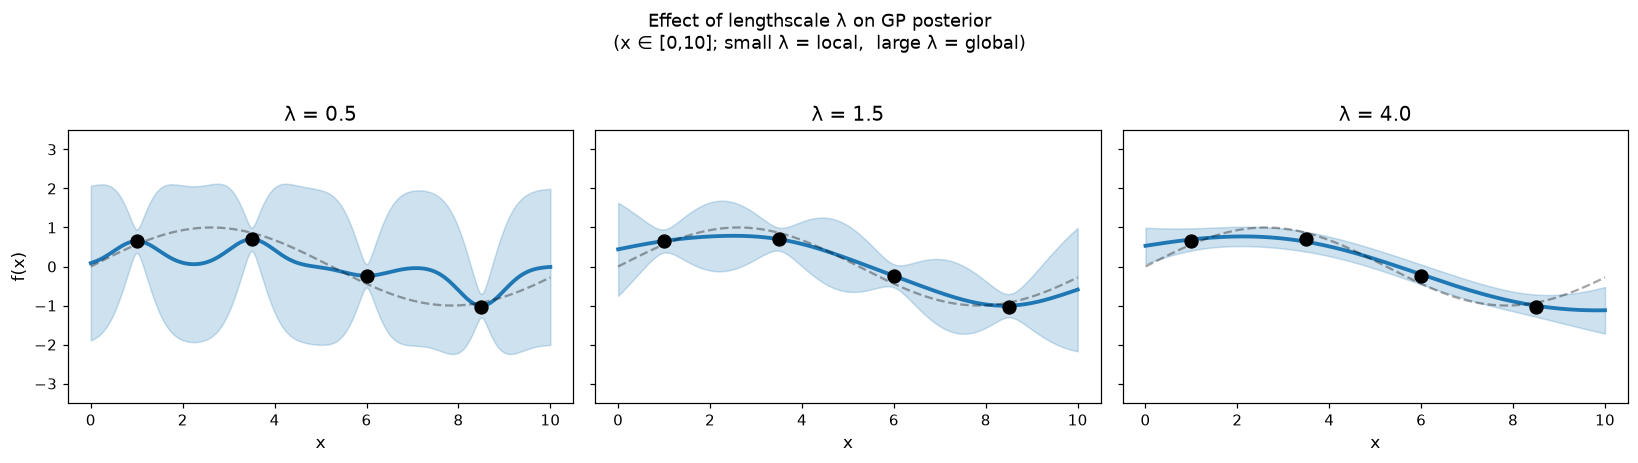

In [8]:
# --- Change these to explore ---
lengthscales = [0.5, 1.5, 4.0]
# --------------------------------

X_obs2 = np.array([1.0, 3.5, 6.0, 8.5])
y_obs2 = true_fn2(X_obs2) + np.array([0.10, -0.15, 0.20, -0.10])

fig, axes = plt.subplots(1, len(lengthscales), figsize=(5 * len(lengthscales), 4), sharey=True)

for ax, ls in zip(axes, lengthscales):
    mu, std, _ = gp_posterior(X_obs2, y_obs2, X_plot2, lengthscale=ls, noise=0.15)
    ax.fill_between(X_plot2, mu - 2*std, mu + 2*std, color='tab:blue', alpha=0.22)
    ax.plot(X_plot2, mu, color='tab:blue', linewidth=2.5, label='Posterior mean')
    ax.plot(X_plot2, true_fn2(X_plot2), 'k--', linewidth=1.5, alpha=0.35, label='True f(x)')
    ax.scatter(X_obs2, y_obs2, color='black', zorder=5, s=70)
    ax.set_title(f'λ = {ls}', fontsize=13)
    ax.set_xlabel('x', fontsize=11)
    ax.set_ylim(-3.5, 3.5)

axes[0].set_ylabel('f(x)', fontsize=11)
plt.suptitle('Effect of lengthscale λ on GP posterior\n(x ∈ [0,10]; small λ = local,  large λ = global)',
             fontsize=12, y=1.04)
plt.tight_layout()
plt.show()

---
## 3. The Spatially Correlated Bandit

Now let's build the task. We'll use a **2D grid of 11 × 11 = 121 options**, indexed by coordinates in $[0, 10]^2$ - so adjacent tiles are exactly 1 unit apart. The reward of each tile is drawn from a GP *prior* with a chosen lengthscale, so nearby tiles tend to have similar rewards. On top of this, each observation is perturbed by Gaussian noise.

This task was introduced in **Wu et al. (2018)** as a model of structured exploration in humans. Participants navigated a 11×11 grid and could sample any tile. The two environment conditions were:
- **Rough environment** ($\lambda = 1$): a tile's reward is informative only about its direct neighbours.
- **Smooth environment** ($\lambda = 2$): rewards are correlated across a wider neighbourhood - a good tile signals that the whole surrounding region is likely good.

**Exercise 4.** Before running the cell below, predict: for which lengthscale do you expect a GP agent to outperform random search the most? Why?

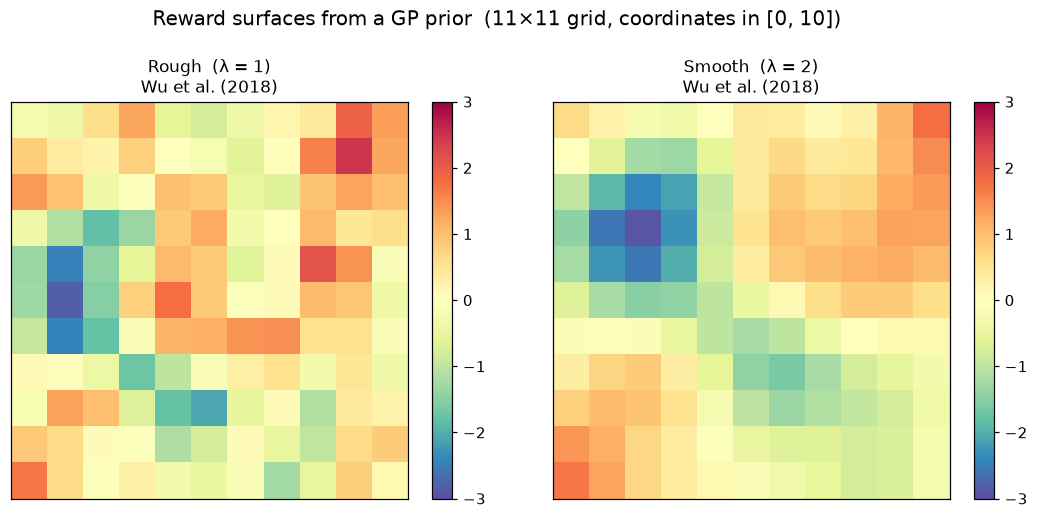

In [9]:
def make_grid_coords(grid_size):
    """Return (n_options, 2) coordinates in [0, 10]^2."""
    xs = np.linspace(0, 10, grid_size)
    return np.array([[x, y] for x in xs for y in xs])


def generate_reward_surface(grid_size, lengthscale, seed=0):
    """
    Sample a 2D reward surface from a GP prior.

    Returns
    -------
    coords       : (n_options, 2)  grid coordinates in [0,10]^2
    true_rewards : (n_options,)    true (latent) reward values
    """
    rng    = np.random.RandomState(seed)
    coords = make_grid_coords(grid_size)
    n      = len(coords)
    K      = rbf_kernel(coords, coords, lengthscale) + 1e-6 * np.eye(n)
    L      = np.linalg.cholesky(K)
    return coords, L @ rng.randn(n)


def show_reward_surface(true_rewards, grid_size, title='', ax=None, vmin=None, vmax=None):
    grid   = true_rewards.reshape(grid_size, grid_size)
    own    = ax is None
    if own:
        fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(grid, cmap='Spectral_r', origin='lower', aspect='equal',
                   vmin=vmin, vmax=vmax, interpolation='nearest')
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(title, fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])
    if own:
        plt.tight_layout(); plt.show()


# Visualise: three environments spanning rough to smooth
GRID_SIZE = 11

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
env_settings = [
    (1.0, 'Rough  (λ = 1)\nWu et al. (2018)'),
    (2.0, 'Smooth  (λ = 2)\nWu et al. (2018)'),
]

for ax, (ls, label) in zip(axes, env_settings):
    _, rewards = generate_reward_surface(GRID_SIZE, ls, seed=7)
    show_reward_surface(rewards, GRID_SIZE, title=label, ax=ax, vmin=-3, vmax=3)

plt.suptitle('Reward surfaces from a GP prior  (11×11 grid, coordinates in [0, 10])', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### What 'spatially correlated' looks like in practice

The two panels above show the same type of environment at two correlation scales. With $\lambda = 1$ (rough, Wu et al. 2018), adjacent tiles are correlated and there is visible local structure. With $\lambda = 2$ (smooth, Wu et al. 2018), the correlation extends over several tiles, creating broad peaks and valleys that make generalisation much more rewarding.

In the Wu et al. (2018) experiments, participants played in both conditions. The key finding was that human participants generalised across options in a manner consistent with the GP-UCB model, showing a stronger tendency to choose tiles near high-reward areas in the smooth condition, where wider correlations made that strategy more effective.

**Exercise 5.** Change the `seed` below. How much does the specific surface vary across seeds? Does the statistical character (smooth vs rough) remain stable? This matters when designing experiments: results should be averaged over multiple independent reward landscapes.

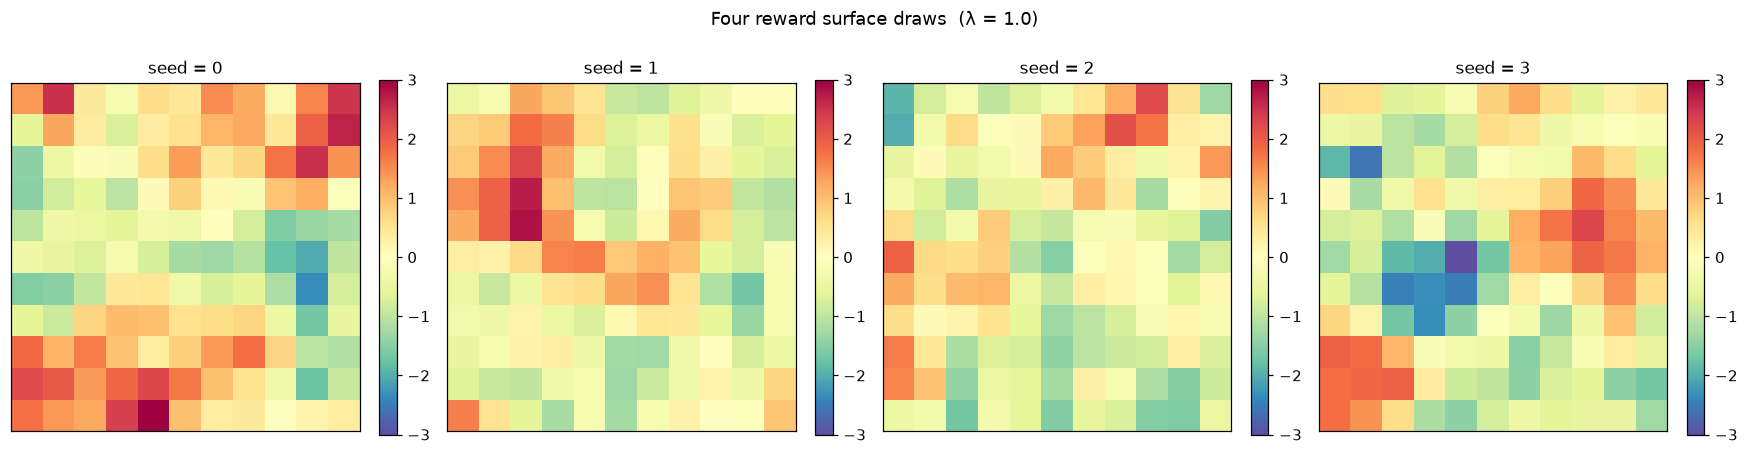

In [10]:
# Explore different seeds - same lengthscale, different realizations
# --- Change these ---
env_lengthscale = 1.0    # try 1.0 (rough) or 2.0 (smooth)
seeds_to_show   = [0, 1, 2, 3]
# --------------------

fig, axes = plt.subplots(1, len(seeds_to_show), figsize=(4 * len(seeds_to_show), 4))
for ax, s in zip(axes, seeds_to_show):
    _, rewards = generate_reward_surface(GRID_SIZE, env_lengthscale, seed=s)
    show_reward_surface(rewards, GRID_SIZE, title=f'seed = {s}', ax=ax, vmin=-3, vmax=3)

plt.suptitle(f'Four reward surface draws  (λ = {env_lengthscale})', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## 4. The GP-UCB Agent

We now have all the ingredients. Let's build the agent.

**GP-UCB** (Srinivas et al., 2010) selects options using an **Upper Confidence Bound** acquisition function:
$$
\mathrm{UCB}(x) = \mu_t(x) + \beta \cdot \sigma_t(x)
$$
where $\mu_t$ and $\sigma_t$ are the GP posterior mean and std after $t$ observations, and $\beta \geq 0$ is an **exploration bonus**:
- When $\beta = 0$: pure exploitation, meaning the agent always chooses the tile with the highest estimated value
- When $\beta > 0$: uncertain tiles get a bonus proportional to their uncertainty, encouraging exploration

To match human choice stochasticity, we apply a **softmax** with temperature $\tau$:
$$
P(x) = \frac{\exp(\mathrm{UCB}(x) / \tau)}{\sum_{x'} \exp(\mathrm{UCB}(x') / \tau)}
$$
Small $\tau$ → near-deterministic choice of the highest-UCB tile. Large $\tau$ → more stochastic choices.

**Parameters from Wu et al. (2018) human data (Exp. 2):**

| Parameter | Cognitive meaning | Fitted value (avg.) |
|---|---|---|
| **λ = 0.67** | Generalization distance | Smaller than environment λ - people under-smooth |
| **β = 0.52** | Exploration bonus | Modest directed exploration |
| **τ = 0.10** | Choice stochasticity | Largely deterministic with some noise |

Day 2 will show how to *recover* these parameters from participant choice data. Today we use them to simulate a human-like agent.

### The algorithm, step by step:

1. **Prior**: start with $\mu_0(x) = 0$, $\sigma_0(x) = 1$ for all $x$
2. **UCB**: compute $\mathrm{UCB}(x) = \mu_t(x) + \beta \cdot \sigma_t(x)$
3. **Choose**: softmax over UCB scores with temperature $\tau$
4. **Observe**: receive noisy reward $y = f(x) + \varepsilon$
5. **Update**: recompute GP posterior with the new observation
6. Repeat

In [11]:
def run_gp_ucb(
    coords, true_rewards,
    n_rounds=30,
    lengthscale=0.67,   # lambda: extent of generalization
    beta=0.52,           # exploration bonus
    tau=0.10,            # softmax temperature
    noise_std=0.10,      # observation noise
    seed=0
):
    """
    Run GP-UCB on a 2D bandit.

    Returns a history dict with per-round choices, rewards, and posteriors.
    """
    rng       = np.random.RandomState(seed)
    n_options = len(coords)

    X_obs_idx = []
    y_obs     = []
    history   = {'choices': [], 'rewards': [],
                 'mu': [], 'std': [], 'ucb': []}

    for t in range(n_rounds):
        if len(X_obs_idx) == 0:
            mu  = np.zeros(n_options)
            std = np.ones(n_options)
        else:
            mu, std, _ = gp_posterior(
                coords[X_obs_idx], np.array(y_obs),
                coords, lengthscale, noise_std
            )

        ucb    = mu + beta * std
        logits = (ucb - ucb.max()) / tau
        probs  = np.exp(np.clip(logits, -500, 0))
        probs /= probs.sum()
        choice = rng.choice(n_options, p=probs)

        reward = true_rewards[choice] + rng.randn() * noise_std
        X_obs_idx.append(choice)
        y_obs.append(reward)
        history['choices'].append(choice)
        history['rewards'].append(reward)
        history['mu'].append(mu.copy())
        history['std'].append(std.copy())
        history['ucb'].append(ucb.copy())

    return history


def run_random_agent(true_rewards, n_rounds=30, noise_std=0.10, seed=0):
    rng      = np.random.RandomState(seed)
    choices  = rng.choice(len(true_rewards), size=n_rounds, replace=True)
    rewards  = [true_rewards[c] + rng.randn() * noise_std for c in choices]
    return {'choices': list(choices), 'rewards': rewards}


print('GP-UCB agent ready.')

GP-UCB agent ready.


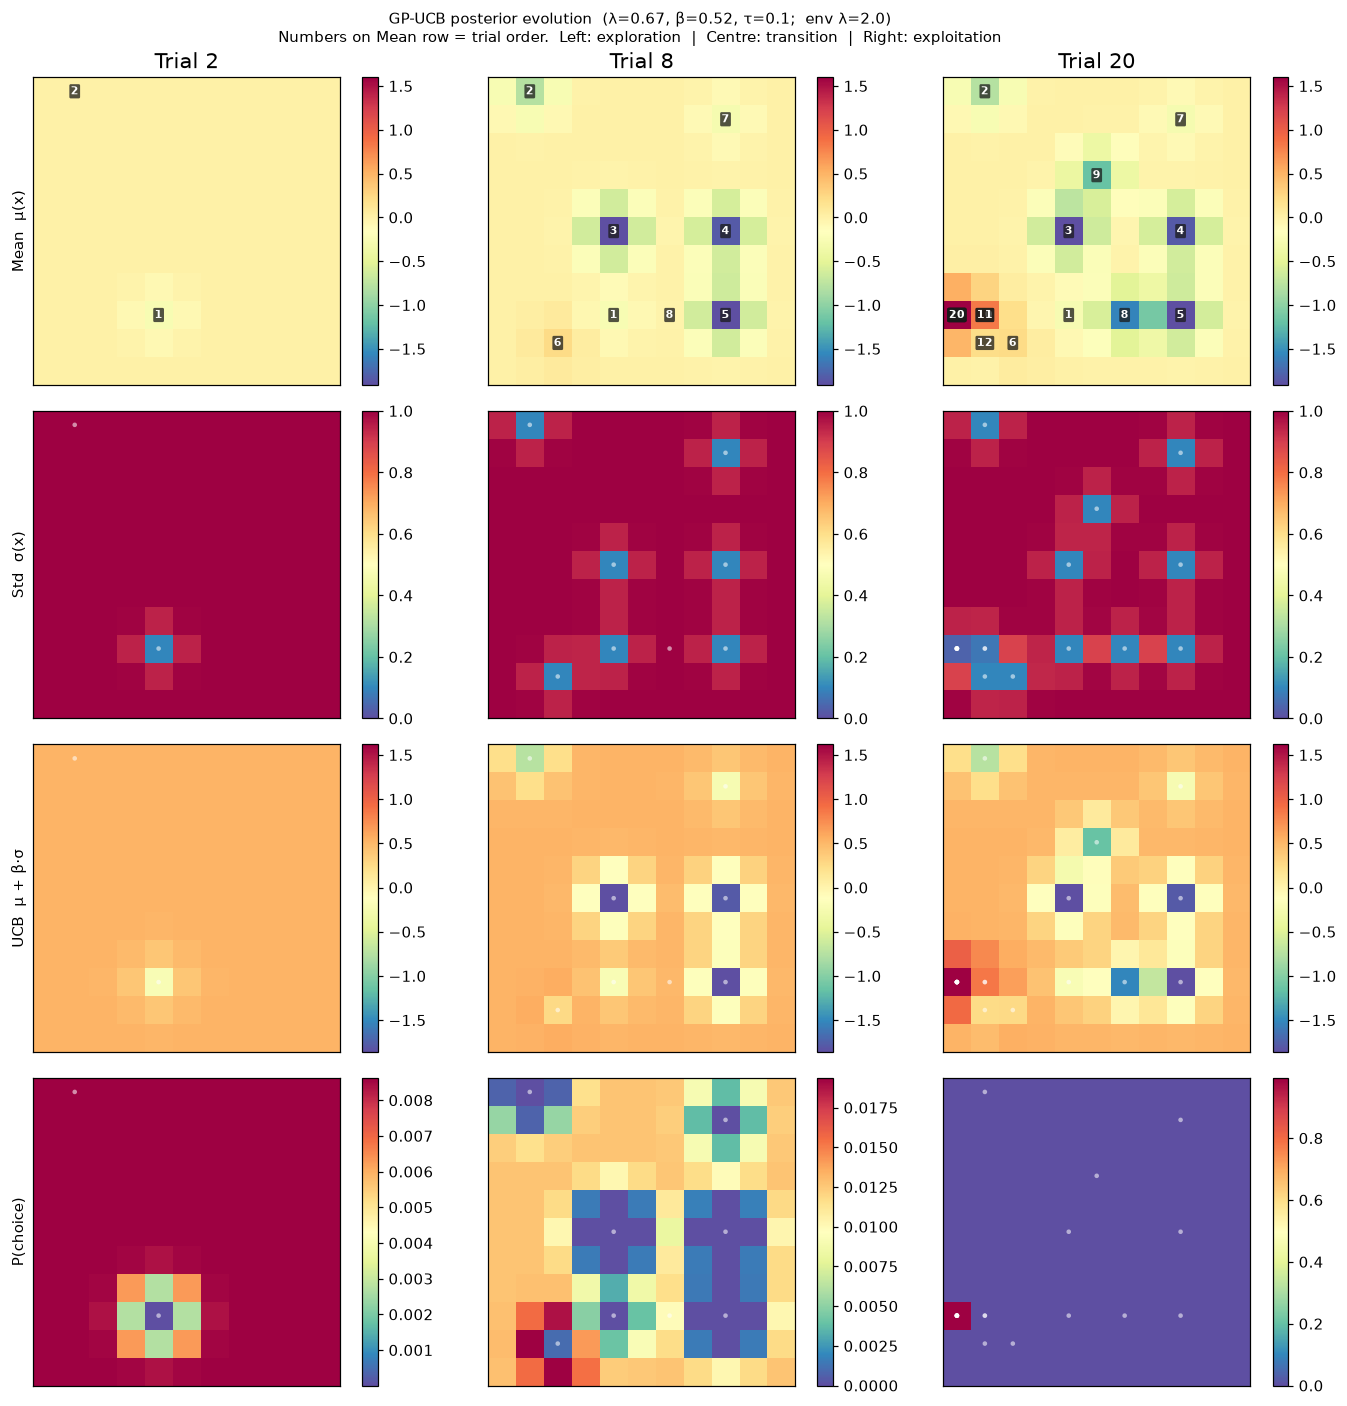

In [12]:
# Run agent and visualise the evolving posterior at three diagnostic time points.
# ENV_SEED=84 (smooth, λ=2) has a moderate isolated reward peak that requires ~10 trials
# to find, producing three visually distinct phases across the panels.
#
# Trial  2 - exploration:  agent near-prior, uniform uncertainty, mean flat
# Trial  8 - transition:   agent has spread out across the grid, posterior structure emerging
# Trial 20 - exploitation: choices clustered in high-reward region, low uncertainty there

ENV_SEED  = 84
ENV_LS    = 2.0
NOISE_STD = 0.10
AGENT_LS  = 0.67    # human-matched lengthscale (Wu et al. 2018)
BETA      = 0.52    # human-matched exploration bonus
TAU       = 0.10    # human-matched softmax temperature
N_TRIALS  = 30

coords, true_rewards = generate_reward_surface(GRID_SIZE, ENV_LS, seed=ENV_SEED)
history = run_gp_ucb(coords, true_rewards, n_rounds=N_TRIALS,
                     lengthscale=AGENT_LS, beta=BETA, tau=TAU,
                     noise_std=NOISE_STD, seed=5)

trials_to_show = [1, 7, 19]   # 0-indexed -> trials 2, 8, 20

def ucb_to_probs(ucb_flat, tau):
    logits = (ucb_flat - ucb_flat.max()) / tau
    probs  = np.exp(np.clip(logits, -500, 0))
    return probs / probs.sum()

all_mus   = [history['mu'][t].reshape(GRID_SIZE, GRID_SIZE)              for t in trials_to_show]
all_stds  = [history['std'][t].reshape(GRID_SIZE, GRID_SIZE)             for t in trials_to_show]
all_ucbs  = [history['ucb'][t].reshape(GRID_SIZE, GRID_SIZE)             for t in trials_to_show]
all_probs = [ucb_to_probs(history['ucb'][t], TAU).reshape(GRID_SIZE, GRID_SIZE)
             for t in trials_to_show]

row_labels  = ['Mean  \u03bc(x)', 'Std  \u03c3(x)', 'UCB  \u03bc + \u03b2\u00b7\u03c3', 'P(choice)']
CMAP        = 'Spectral_r'
row_vranges = [
    (min(d.min() for d in all_mus),   max(d.max() for d in all_mus)),
    (0,                                max(d.max() for d in all_stds)),
    (min(d.min() for d in all_ucbs),  max(d.max() for d in all_ucbs)),
    None,   # P(choice): per-panel range so contrast adapts to each time point
]

fig = plt.figure(figsize=(13, 13))

for col, t in enumerate(trials_to_show):
    mu    = all_mus[col]
    std   = all_stds[col]
    ucb   = all_ucbs[col]
    probs = all_probs[col]

    chosen_flat = history['choices'][:t + 1]
    chosen_rows = [c // GRID_SIZE for c in chosen_flat]
    chosen_cols = [c  % GRID_SIZE for c in chosen_flat]

    for row, (data, lbl, vrange) in enumerate(
            zip([mu, std, ucb, probs], row_labels, row_vranges)):
        ax = fig.add_subplot(4, 3, row * 3 + col + 1)
        vmin, vmax = vrange if vrange is not None else (data.min(), data.max())
        im = ax.imshow(data, cmap=CMAP, origin='lower', aspect='equal',
                       vmin=vmin, vmax=vmax, interpolation='nearest')
        plt.colorbar(im, ax=ax, fraction=0.046)

        if row == 0:
            # Mean panel: show full numbered trajectory so the exploration path is legible
            for i, (r, c) in enumerate(zip(chosen_rows, chosen_cols)):
                ax.text(c, r, str(i + 1),
                        ha='center', va='center', fontsize=7.5, fontweight='bold',
                        color='white',
                        bbox=dict(boxstyle='round,pad=0.12', facecolor='#1a1a1a',
                                  alpha=0.75, edgecolor='none'),
                        zorder=5)
        else:
            # Other rows: small dots so the spatial pattern stays readable
            ax.scatter(chosen_cols, chosen_rows,
                       s=9, c='white', alpha=0.55, zorder=4, edgecolors='none')

        ax.set_xticks([])
        ax.set_yticks([])

        if row == 0:
            ax.set_title(f'Trial {t + 1}', fontsize=14)
        if col == 0:
            ax.set_ylabel(lbl, fontsize=10)

plt.suptitle(
    f'GP-UCB posterior evolution  (\u03bb={AGENT_LS}, \u03b2={BETA}, \u03c4={TAU};  env \u03bb={ENV_LS})\n'
    f'Numbers on Mean row = trial order.  '
    f'Left: exploration  |  Centre: transition  |  Right: exploitation',
    fontsize=10
)
plt.tight_layout()
plt.show()

### Reading the posterior panels

Read each column (a single time point) top-to-bottom:

1. **Mean $\mu(x)$** is the agent's current estimate of the reward surface. Early on it's mostly flat (prior); as data accumulates, peaks and valleys emerge. Notice how a single observation creates a "bump" in the mean that extends to nearby tiles - this is the GP generalising through the kernel.
2. **Std $\sigma(x)$** captures uncertainty, which is initially high everywhere. After each observation, uncertainty collapses near that tile *and its neighbours*, since the GP infers that nearby tiles are probably similar and therefore less uncertain.
3. **UCB = $\mu + \beta \cdot \sigma$** is what the agent actually scores each tile. The chosen tile (gold number, most recent) tends to lie near a UCB peak, balancing value and uncertainty.

The trial numbers reveal the **exploration trajectory**: early trials tend to spread out (high uncertainty everywhere); later trials cluster around promising regions.

**Exercise 6.** Set `BETA = 0.0` (pure exploitation). Does the agent get stuck revisiting a few high-value tiles? Now try `BETA = 3.0`. Does it explore too broadly?

**Exercise 7.** Set `AGENT_LS = 0.3` while keeping `ENV_LS = 2.0`. The agent now assumes the environment is rougher than it actually is, causing it to under-generalise. How does the posterior mean change? Does the agent still find good tiles, or does it waste trials exploring near each observation individually?

### Explore: Interactive parameter tuning

The three parameters map directly onto the features used in Day 2's choice model, though with a more flexible formulation:

| Parameter | Cognitive meaning | What happens at the extremes | Day 2 counterpart |
|---|---|---|---|
| **λ** | How broadly does the agent generalise from each observation? | Small λ → treats every tile as independent; large λ → one observation influences the whole grid | **λ** (same role: fitted by MLE) |
| **β** | How much weight on uncertainty vs expected value? | β=0 → always exploit; large β → always explore most uncertain tile | Absorbed into the **probit link**: uncertainty automatically attenuates the logit without a free β |
| **τ** | How stochastic are choices? | τ→0 → deterministic argmax; τ→∞ → random | Replaced by **w_mean**: scales the logit of the probit approximation, acting as an inverse temperature on the GP mean |

In Day 2, the single UCB score μ + β·σ is replaced by a **General Linear Model (GLM)** where each feature (GP mean, locality, and optionally GP std) gets its own weight. β and τ disappear as explicit parameters: β's role (exploration) is taken over by the probit approximation, and τ's role (choice stochasticity) is captured by the scale of w_mean. A new **locality weight w_local** is added to capture the fact that participants move physically and strongly prefer nearby blocks.

**Exercise 8.** Try `env_ls = 1.0` (rough) vs `env_ls = 2.0` (smooth) while keeping agent parameters fixed. In which environment does GP-UCB gain more over the random baseline? Why?

**Exercise 9.** Set `agent_ls = 0.3` while `env_ls = 2.0`. This is *model misspecification* — the agent assumes the environment is rougher than it is. How much does cumulative reward drop? Can you compensate by increasing `beta`?


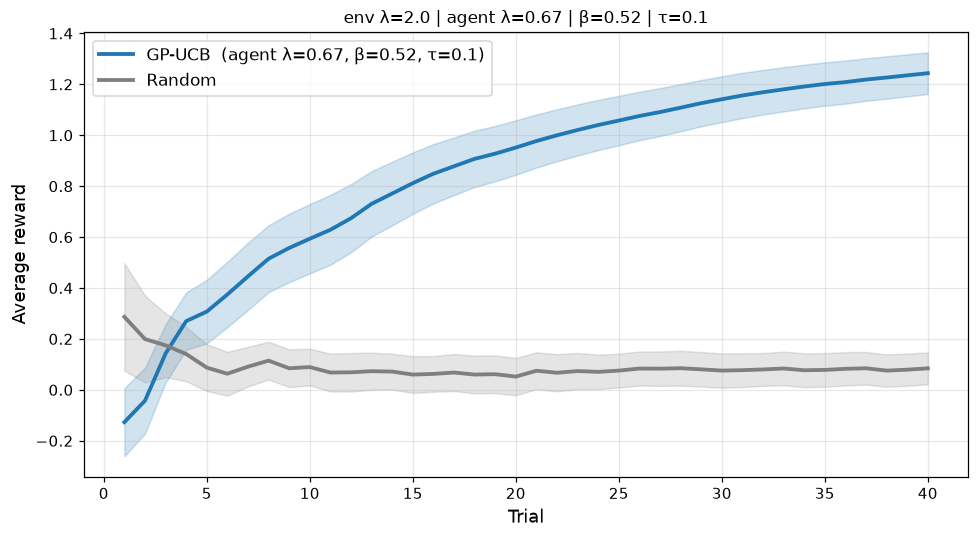

GP-UCB average reward (trial 40): 1.24
Random average reward (trial 40): 0.08
GP advantage: +1.16


In [13]:
# === Adjust these and re-run ===
env_ls   = 2.0     # true environment lengthscale (try 1.0 = rough, 2.0 = smooth)
agent_ls = 0.67    # agent's assumed lengthscale
beta     = 0.52    # exploration bonus
tau      = 0.10    # softmax temperature
n_rounds = 40
# ================================

n_envs = 30
gp_r, rand_r = [], []

for s in range(n_envs):
    c, tr = generate_reward_surface(GRID_SIZE, env_ls, seed=s)
    gp_r.append(run_gp_ucb(c, tr, n_rounds=n_rounds,
                            lengthscale=agent_ls, beta=beta, tau=tau,
                            noise_std=NOISE_STD, seed=s)['rewards'])
    rand_r.append(run_random_agent(tr, n_rounds=n_rounds,
                                   noise_std=NOISE_STD, seed=s)['rewards'])

gp_r, rand_r = np.array(gp_r), np.array(rand_r)
gp_avg_r   = np.cumsum(gp_r,   axis=1) / np.arange(1, n_rounds + 1)
rand_avg_r = np.cumsum(rand_r, axis=1) / np.arange(1, n_rounds + 1)
rs         = np.arange(1, n_rounds + 1)

fig, ax = plt.subplots(figsize=(9, 5))
for arr, color, label in [
    (gp_avg_r,   'tab:blue', f'GP-UCB  (agent λ={agent_ls}, β={beta}, τ={tau})'),
    (rand_avg_r, 'tab:gray', 'Random'),
]:
    m = arr.mean(0); se = arr.std(0) / np.sqrt(n_envs)
    ax.plot(rs, m, color=color, linewidth=2.5, label=label)
    ax.fill_between(rs, m - se, m + se, color=color, alpha=0.2)

ax.set_xlabel('Trial', fontsize=12)
ax.set_ylabel('Average reward', fontsize=12)
ax.set_title(f'env λ={env_ls} | agent λ={agent_ls} | β={beta} | τ={tau}', fontsize=11)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'GP-UCB average reward (trial {n_rounds}): {gp_avg_r[:, -1].mean():.2f}')
print(f'Random average reward (trial {n_rounds}): {rand_avg_r[:, -1].mean():.2f}')
print(f'GP advantage: {gp_avg_r[:, -1].mean() - rand_avg_r[:, -1].mean():+.2f}')

---
## 5. Scaling to Grid-World Foraging

### From static bandit to sequential foraging

The bandit setting in Sections 3–4 is a clean testbed, but it omits something important: **movement**. In the Wu et al. (2025) foraging task, participants navigate a 2D grid-world where their *position* matters: they incur a travel cost when moving between tiles, and rewards can only be collected by physically visiting a location. This is a form of the **explore-exploit dilemma** embedded in space: to reach a distant high-reward block, the agent must pass through and forego the rewards of other blocks they pass by.

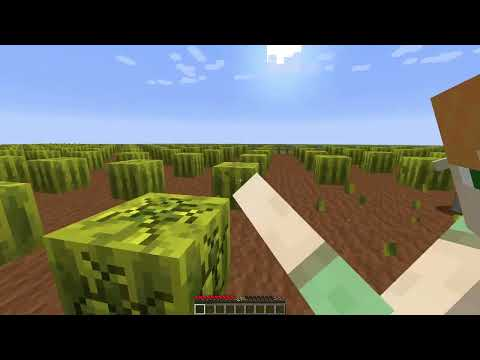

In [14]:
from IPython.display import YouTubeVideo
YouTubeVideo('wyk7RbmHiok', width=800, height=300)
#https://www.youtube.com/watch?v=wyk7RbmHiok

Crucially, the reward surface is still drawn from a GP prior. However, here rewards are binarized (indicated by a blue splash when a block is destroyed), such that the top quartile (25%) of block locations were set to contain rewards, while the rest had no rewards. This means the GP posterior can still track the spatial structure of rewards, but a **probit link** is needed to convert the continuous GP output into a binary reward probability. The "What Day 2 will build on this" section below explains this in detail.

Day 2 will focus on fitting an adapted GP choice model to participant data from the solo + smooth environments condition, recovering individual parameters and comparing models to understand what drives foraging behaviour.

### Dataset

The cells below load and visualise data from **Wu et al. (2025)**, in which four participants navigated a **20×20 Minecraft grid** across 32 sessions of 16 rounds each. Block coordinates span $[2, 59]$ in steps of 3 (i.e., blocks are 3 units apart). Each session had both a **solo** condition (each player foraging alone) and a **group** condition (four players foraging together), and the reward surface was either **smooth** ($\lambda = 4$, spatially correlated) or **random** (uncorrelated). Note that here, rewards are **binary** (true vs. false) and **once a block is destroyed it cannot be sampled again** (in contrast to the spatially correlated bandit; Wu et al., 2018)


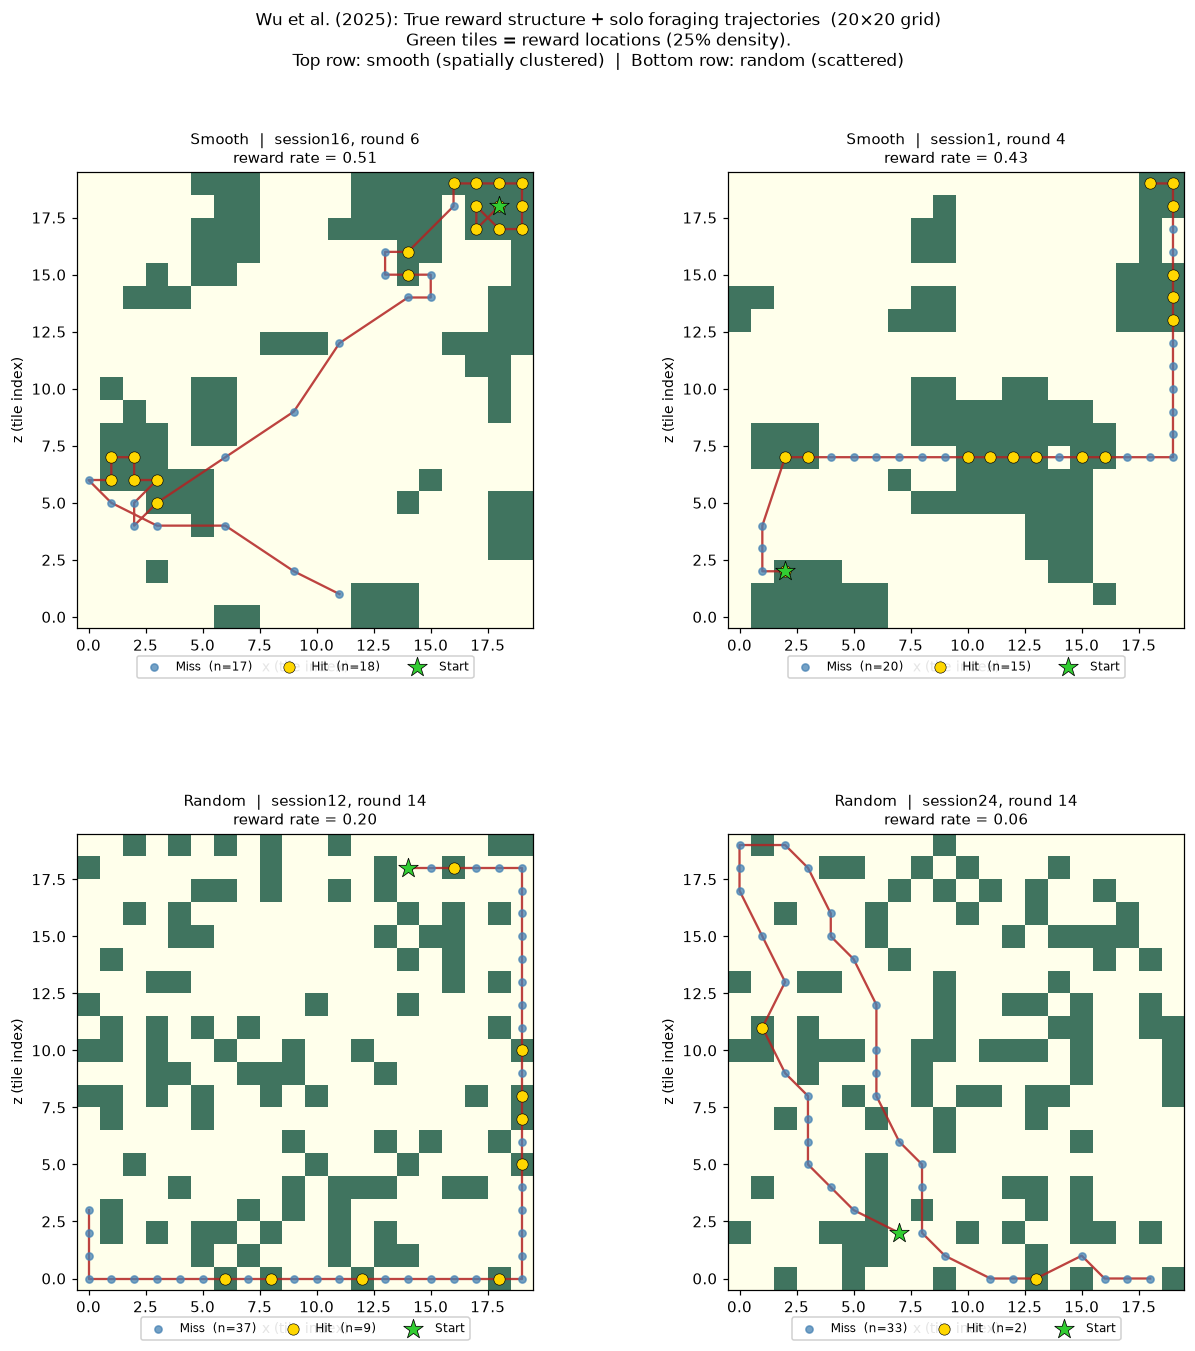

Solo condition summary:
Env      | Reward rate
-------------------------
smooth   |       0.430
random   |       0.246


In [15]:
import pandas as pd

df = pd.read_feather('data/wu2025minecraft.feather')

x_vals = np.array(sorted(df['x'].unique()))
z_vals = np.array(sorted(df['z'].unique()))
FGRID  = 20

def to_idx(vals, lookup):
    return np.searchsorted(lookup, vals)

def load_env_grid(path):
    """Load 20×20 binary reward grid (1=reward) from semicolon-delimited CSV."""
    return pd.read_csv(path, sep=';', header=0, index_col=0).values.astype(int)

def get_solo_traj(session, round_num, env_type, name=None):
    """Return sorted trajectory for a solo round; if name given, filter to that participant."""
    sub = df[(df['type'] == 'solo') & (df['env'] == env_type) &
             (df['session'] == session) & (df['round'] == round_num)]
    if name is not None:
        sub = sub[sub['name'] == name]
    if len(sub) == 0:
        return None
    p = sub['name'].iloc[0]
    return sub[sub['name'] == p].sort_values('time')

# Four panels, each a different participant from a different session.
# All examples selected for near-full grid coverage (bbox ≥ 306 out of 19×19 possible).
panels = [
    ('environments/smooth.12.csv', 'session16.json',  6,  'smooth', 'MPIB2'),  # bbox=342
    ('environments/smooth.3.csv',  'session1.json',   4,  'smooth', 'MPIB3'),  # bbox=306
    ('environments/random.14.csv', 'session12.json',  14, 'random', 'MPIB1'),  # bbox=342
    ('environments/random.19.csv', 'session24.json',  14, 'random', 'MPIB4'),  # bbox=342
]

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

for idx, (csv_path, session, round_num, env_type, pname) in enumerate(panels):
    ax   = axes.flat[idx]
    grid = load_env_grid(csv_path)

    ax.imshow(grid, cmap='YlGn', origin='lower', aspect='equal',
              alpha=0.75, vmin=0, vmax=1)

    traj = get_solo_traj(session, round_num, env_type, name=pname)
    if traj is not None:
        xi_t  = to_idx(traj['x'].values, x_vals)
        zi_t  = to_idx(traj['z'].values, z_vals)
        rew_t = traj['reward'].values.astype(bool)
        n_hit = int(rew_t.sum())
        n_all = len(traj)

        ax.plot(xi_t, zi_t, '-', color='firebrick', linewidth=1.5, alpha=0.85, zorder=2)
        ax.scatter(xi_t[~rew_t], zi_t[~rew_t],
                   c='steelblue', s=22, zorder=3, alpha=0.75,
                   label=f'Miss  (n={(~rew_t).sum()})')
        ax.scatter(xi_t[rew_t], zi_t[rew_t],
                   c='gold', s=55, zorder=4,
                   edgecolors='black', linewidths=0.4,
                   label=f'Hit  (n={n_hit})')
        ax.scatter(xi_t[0], zi_t[0],
                   marker='*', s=180, c='limegreen', zorder=5,
                   edgecolors='black', linewidths=0.5, label='Start')

        sesh_id = session.replace('.json', '')
        ax.set_title(
            f'{env_type.capitalize()}  |  {sesh_id}, round {round_num}\n'
            f'reward rate = {n_hit / n_all:.2f}',
            fontsize=10
        )
        ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.06),
                  ncol=3, framealpha=0.9, borderaxespad=0)

    ax.set_xlim(-0.5, FGRID - 0.5)
    ax.set_ylim(-0.5, FGRID - 0.5)
    ax.set_xlabel('x (tile index)', fontsize=9)
    ax.set_ylabel('z (tile index)', fontsize=9)

plt.suptitle(
    'Wu et al. (2025): True reward structure + solo foraging trajectories  (20×20 grid)\n'
    'Green tiles = reward locations (25% density).\n'
    'Top row: smooth (spatially clustered)  |  Bottom row: random (scattered)',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.subplots_adjust(hspace=0.45)
plt.show()

print('Solo condition summary:')
print(f'{"Env":8s} | {"Reward rate":>11s}')
print('-' * 25)
for env in ['smooth', 'random']:
    sub = df[(df['type'] == 'solo') & (df['env'] == env)]
    print(f'{env:8s} | {sub["reward"].mean():>11.3f}')

### What Day 2 will build on this

Today we built the GP-UCB model from scratch and saw how it behaves as an agent. Day 2 reverses the question: **given a participant's choices, what model best explains their behaviour?**

**From GP-UCB to a GLM with a probit link**

The GP-UCB model from Block 3 folds everything into a single UCB score passed through a softmax. The Wu et al. (2025) foraging context calls for a more flexible approach using a **General Linear Model (GLM)** in which any arbitrary set of features (e.g., GP mean, locality, social features) each get their own independent weight, making it straightforward to add, remove, or compare features.

$$
P(\text{Choice}_{k+1}) \propto \exp(\mathbf{f}_k\cdot \mathbf{w})
$$

Because rewards in the Minecraft task are **binary** (hit or miss), the GP does not predict reward values directly. Instead, it places a prior over a **latent function** $z(\mathbf{x})$, linked to reward probability via the logistic sigmoid:
$$p(r\!=\!1|\mathbf{x}) = S(z(\mathbf{x})) = \frac{1}{1+e^{-z(\mathbf{x})}}$$
A value $z=0$ corresponds to the prior reward probability (set to 0.25 via the prior mean $z_0 = \log\frac{0.25}{0.75}$). Positive values of $z$ increases it above chance, while negative $z$ decreases it below.

The GP posterior over the latent function given observed binary rewards is approximately Gaussian at each location, $z(\mathbf{x})\mid\mathcal{D} \approx \mathcal{N}(\mu_z(\mathbf{x}),\,\sigma^2_z(\mathbf{x}))$. To obtain an estimated reward probability we integrate out the latent uncertainty using the **probit link** (Bishop, 2006):
$$\hat{p}(r\!=\!1|\mathbf{x}) \approx S\!\left(\frac{\mu_z(\mathbf{x})}{\sqrt{1 + \frac{\pi}{8}\,\sigma^2_z(\mathbf{x})}}\right)$$
Tiles with high latent mean $\mu_z$ are predicted to be rewarding; high latent variance $\sigma^2_z$ shrinks the estimate toward chance, reflecting that uncertain tiles should not be confidently called rewarding or empty. This probit-adjusted estimate, along with raw GP uncertainty $\sigma_z(x)$ and a locality feature, then enters the Day 2 GLM softmax as separate weighted features.

**Fitting procedure:** Day 2 uses **MLE via scipy.optimize** rather than Bayesian model fitting in STAN implemented in Wu et al., (2025). This allows us to define a model that runs in seconds (rather than days or weeks), needs no probabilistic-programming setup, and is sufficient for 3-4 free parameters and ~150 decisions per participant.

**Primary extension on Day 2: Area-Restricted Search (ARS).** After finding a reward, foragers typically intensify local search. But after a long absence of rewards, they tend to search over larger distances. Here we can define a locality weight that varies *linearly* with $\Delta t$, which is the elapsed time since the last individually-earned reward:

$$\tilde{w}_\text{local}(\Delta t) = w_\text{local} + \rho\,\Delta t$$

A negative $\rho$ recovers classic ARS behaviour: strong locality after a reward, then broader exploration after a long absence. The same linear structure can optionally extend to $w_\text{mean}$.

*Note: additional features based on visibility from Wu et al. (2025) will not covered in Day 2, since it requires field-of-view data that is rather complex and too large to include in this repository.*

---
## Summary

In this notebook we developed GP-UCB as a Bayesian approach to value function approximation in structured environments.

| Concept | Key takeaway |
|---|---|
| **Bayesian Linear Regression** | Posterior over polynomial coefficients → posterior over functions; still limited to the polynomial family |
| **Kernel trick** | Predictions depend only on $k(x, x') = \boldsymbol{\phi}(x)^\top\boldsymbol{\phi}(x')$; defining $k$ directly skips the feature map entirely |
| **RBF kernel** | Corresponds to infinite smooth basis; no oscillation instability; controlled by lengthscale $\lambda$ |
| **GP posterior** | Fully defined by a mean (expected reward) and variance (uncertainty); both can be computed analytically |
| **Lengthscale $\lambda$** | Extent of generalization: how far each observation informs its neighbours |
| **GP-UCB** | $UCB(x) = \mu(x) + \beta\sigma(x)$; softmax with $\tau$; three parameters $(\lambda, \beta, \tau)$ map to exploitation, exploration, and stochasticity |
| **Correlated bandit** | Reward surface is a GP prior sample; structured environments reward appropriate generalization |

**The key parallel with Notebooks 1 and 2:** DYNA-Q used an explicit transition model to plan; CRP-DYNA-Q maintained multiple models indexed by latent context. GP-UCB takes a third route: rather than a discrete model, it maintains a *continuous function estimate* over the option space. The three approaches represent complementary strategies for exploiting structure: temporal (DYNA-Q), contextual (CRP-DYNA-Q), and spatial (GP-UCB).

**Day 2 (Track 2) builds directly on this toolkit**, replacing the UCB+softmax formulation with a **probit-link GLM** fitted to real foraging data. Key differences from today:

| What changes in Day 2 | Why |
|---|---|
| UCB+softmax → **Probit-GP** with separate feature weights | More flexible: each feature (GP mean, locality) gets its own weight|
| No proximity → **Locality feature** $\text{loc}(x)=-\|x - x_\text{curr}\|$ | Participants must physically traverse the space, making local options more likely.|
| Softmax regression $(\lambda,\beta,\tau)$ → **MLE** on $(\lambda, w_\text{mean}, w_\text{local})$ | Faster and sufficient for 3-4 parameters |
| Static weights → **ARS** $\tilde{w}_\text{local}=w_\text{local}+\rho\,\Delta t$ | Area-Restricted Search: locality intensifies right after a reward, then disperses with elapsed time |

**Further reading**

Giron, A. P., Ciranka, S., Schulz, E., van den Bos, W., Ruggeri, A., Meder, B., & Wu, C. M. (2023). Developmental changes in exploration resemble stochastic optimization. *Nature Human Behaviour*, 7(11), 1955-1967. https://doi.org/10.1038/s41562-023-01662-1

Rasmussen, C. E., & Williams, C. K. I. (2006). *Gaussian Processes for Machine Learning*. MIT Press. https://doi.org/10.7551/mitpress/3206.001.0001

Schulz, E., Speekenbrink, M., & Krause, A. (2018). A tutorial on Gaussian process regression: Modelling, exploring, and exploiting functions. *Journal of Mathematical Psychology*, 85, 1-16. https://doi.org/10.1016/j.jmp.2018.03.001

Srinivas, N., Krause, A., Kakade, S. M., & Seeger, M. W. (2010). Gaussian process optimization in the bandit setting: No regret and experimental design. *ICML 2010*, 1015-1022. https://doi.org/10.48550/arXiv.0912.3995

Ten, A., Sakaki, M., Breit, S., Chandrasekaran, A., Murayama, K., & Wu, C. M. (2025). In search of lost memories: Modeling exploration with forgetful generalization. *PsyArxiv*. https://doi.org/10.31234/osf.io/hupq5_v1

Witt, A., Toyokawa, W., Lala, K. N., Gaissmaier, W., & Wu, C. M. (2024). Humans flexibly integrate social information despite interindividual differences in reward. *Proceedings of the National Academy of Sciences*, 121(39), e2404928121. https://doi.org/10.1073/pnas.2404928121

Wu, C. M., Schulz, E., Speekenbrink, M., Nelson, J. D., & Meder, B. (2018). Generalization guides human exploration in vast decision spaces. *Nature Human Behaviour*, 2, 915-924. https://doi.org/10.1038/s41562-018-0467-4

Wu, C. M., Schulz, E., Garvert, M. M., Meder, B., & Schuck, N. W. (2020). Similarities and differences in spatial and non-spatial cognitive maps. *PLOS Computational Biology*, 16, 1–28. https://doi.org/10.1371/journal.pcbi.1008149

Wu, C. M., Schulz, E., & Gershman, S. J. (2021). Inference and search on graph-structured spaces. *Computational Brain & Behavior*, 4, 125–147. https://doi.org/10.1007/s42113-020-00091-x

Wu, C. M., Deffner, D., Kahl, B., Meder, B., Ho, M. K., & Kurvers, R. H. J. M. (2025). Adaptive mechanisms of social and asocial learning in immersive foraging environments. *Nature Communications*, 16, 3539. https://doi.org/10.1038/s41467-025-58365-6